In [2]:
import numpy as np
from scipy.optimize import root_scalar



def compute_P(L, I, Imax, k1, k2, k3, kd,I0):
    x = np.sqrt((k2 * I + 1)**2 + 8 * L * (k2**2 * k3 * I**2 + k1))
    F = np.log(L/2) + np.log((x - (k2*I +1)) / (x + (k2*I +1))) + np.log(kd)
    P = Imax / (1 + np.exp(-F)) + I0
    return P

def inverse_P(P_target, I, Imax, k1, k2, k3, kd,I0, L_bounds=(0, 10)):
    def func(L):
        return compute_P(L, I, Imax, k1, k2, k3, kd,I0) - P_target
    result = root_scalar(func, bracket=L_bounds, method='brentq')
    return result.root

# 参数设定
Imax = 35.84931505
k1, k2, k3 = 0.000268715, 0.007083518, 0.760771692
kd = 6.216347694  # Master curve (kd1)
I0 = 0.035
# 计算 P_EC50
P_EC50 = (Imax+I0) / 2   # 17.934657525

# 求解 L_EC50 for I=0 和 I=100
L_EC50_I0 = inverse_P(P_EC50, I=0, Imax=Imax, k1=k1, k2=k2, k3=k3, kd=kd,I0=I0)
L_EC50_I100 = inverse_P(P_EC50, I=100, Imax=Imax, k1=k1, k2=k2, k3=k3, kd=kd,I0=I0)

print(f"L_EC50 (I=0): {L_EC50_I0:.4e}")
print(f"L_EC50 (I=100): {L_EC50_I100:.4e}")
print(f"Δlog10(L_EC50): {np.log10(L_EC50_I100 / L_EC50_I0):.2f}")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13536\4203926661.py:8: RuntimeWarning: divide by zero encountered in log
  F = np.log(L/2) + np.log((x - (k2*I +1)) / (x + (k2*I +1))) + np.log(kd)


ValueError: f(a) and f(b) must have different signs

[           nan 91550.37656353 89748.5202653  ...   455.90102841
   455.85584935   455.81067927]


C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7332\3022635494.py:30: RuntimeWarning: divide by zero encountered in log
  F1=np.log(L/2)+np.log((x1-(1))/(x1+(1)))+np.log(kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7332\3022635494.py:31: RuntimeWarning: divide by zero encountered in log
  F2=np.log(L/2)+np.log((x2-(1))/(x2+(1)))+np.log(kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7332\3022635494.py:37: RuntimeWarning: divide by zero encountered in divide
  fold=((1/y)*(L/2)*kd)/(1+(L/2)*kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7332\3022635494.py:37: RuntimeWarning: invalid value encountered in multiply
  fold=((1/y)*(L/2)*kd)/(1+(L/2)*kd)


Text(0.5, 1.0, 'K0*c(TF)_fold')

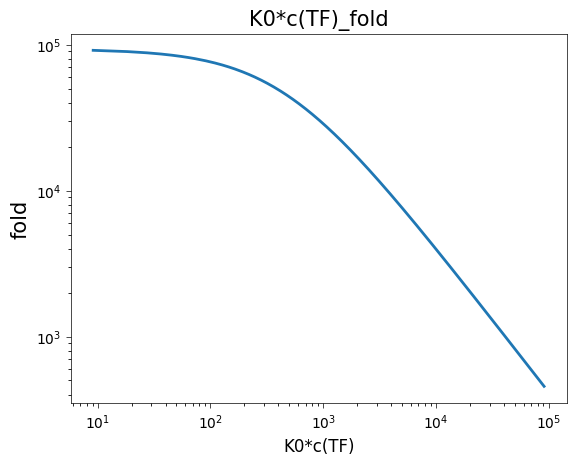

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd


# 设置x和y的坐标范围
L= np.arange(0,10,0.001)
k1= np.arange(0.000109651,0.387876109)
Imax=35.84931505

I0=0.035485714

I=10
k2=0.256016091

k3=225.0817618
m=k2*k2*k3*I*I
Imax=35.84931505
I0=0.111188222


M=1000

kd=40.97704697
x1 = np.sqrt(1+ 8 * L * (M*M*k1)) 
x2 = np.sqrt((1)*(1)+ 8 * L * (k1)) 
F1=np.log(L/2)+np.log((x1-(1))/(x1+(1)))+np.log(kd)
F2=np.log(L/2)+np.log((x2-(1))/(x2+(1)))+np.log(kd)
y=(x2-1)/(x2+1)

P1=(Imax/(1+np.exp(-F1)))+I0
P2=(Imax/(1+np.exp(-F2)))+I0

fold=((1/y)*(L/2)*kd)/(1+(L/2)*kd)
fig, ax = plt.subplots()

ax.plot(L/k1, fold,linewidth=2)

ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("K0*c(TF)",fontsize=12)
ax.set_ylabel("fold",fontsize=15)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5,labelsize=10)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'

# 添加图例并显示图形
print(fold)
plt.title('K0*c(TF)_fold',fontsize=15)

ValueError: operands could not be broadcast together with shapes (1000000,) (2586,) 

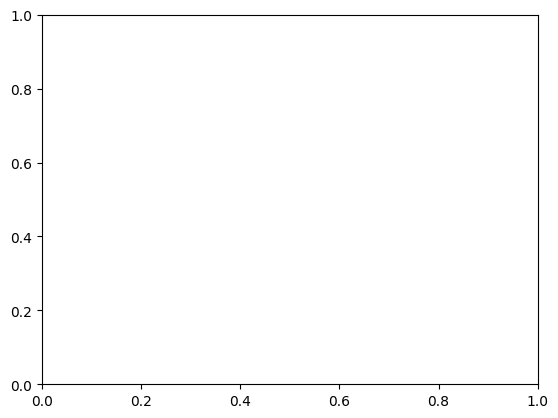

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd


# 设置x和y的坐标范围
I= np.arange(0,10,0.00001)
M= np.arange(3.80584E-07,2585.834721)

Imax=35.84931505

I0=0.035485714

k1=0.387876109

L=0.001

kd=40.97704697
 
x1 = np.sqrt((1)*(1)+ 8 * L * (k1)) 
x2= np.sqrt((1)*(1)+ 8 * L * (M)) 
F1=np.log(L/2)+np.log((x1-(1))/(x1+(1)))+np.log(kd)
F2=np.log(L/2)+np.log((x2-(1))/(x2+(1)))+np.log(kd)
y1=(x1-1)/(x1+1)
y2=(x2-1)/(x2+1)

P1=(Imax/(1+np.exp(-F1)))+I0
P2=(Imax/(1+np.exp(-F2)))+I0

fold=((1/y1)+(L/2)*kd)/((1/y2)+(L/2)*kd)
fig, ax = plt.subplots()

ax.plot(I*M, fold,linewidth=2)

ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("K2K3*c(inducer)",fontsize=12)
ax.set_ylabel("fold",fontsize=15)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5,labelsize=10)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'

# 添加图例并显示图形
print(fold)
plt.title('K2K3*c(inducer)_fold',fontsize=15)

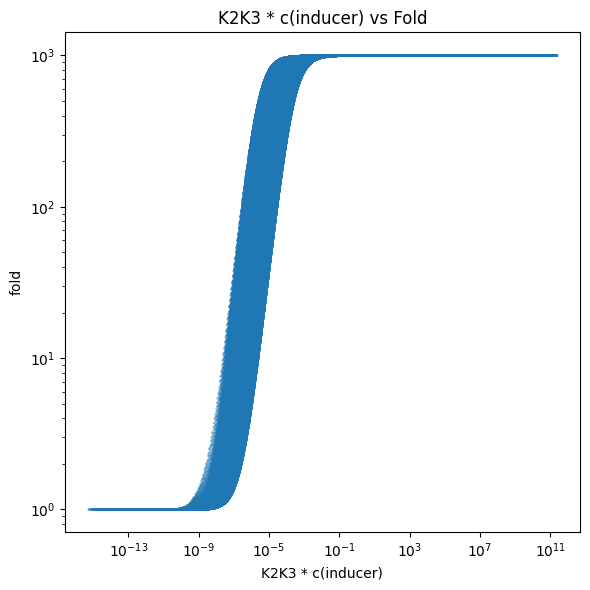

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# 定义变量范围（使用 logspace 确保横轴可对数）
I_vals = np.logspace(-2, 1, 200)        # I: 0.01 ~ 100
k2_vals = np.logspace(-5, 3.5, 100)     # k2^2: ~1e-5 ~ 3e3 => sqrt 就是 0.003~50+
k3_vals = np.linspace(0.05, 225, 100)   # k3

# 网格组合所有变量
I, k2, k3 = np.meshgrid(I_vals, k2_vals, k3_vals, indexing='ij')

# 常量
Imax = 35.84931505
I0 = 0.035485714
k1 = 0.387876109
L = 10
kd = 40.97704697

# 固定项
x1 = np.sqrt(1 + 8 * L * k1)
y1 = (x1 - 1) / (x1 + 1)

# 激活项
m = I**2 * k2**2 * k3
x2 = np.sqrt(1 + 8 * L * m)
y2 = (x2 - 1) / (x2 + 1)
P1=(Imax/(1+np.exp(-F1)))+I0
P2=(Imax/(1+np.exp(-F2)))+I0

# 计算 fold
fold = P2/I0

# 横轴数据
x_axis = (I**2 * k2**2 * k3).flatten()
fold_vals = fold.flatten()

# 排除无效数据
mask = (~np.isnan(fold_vals)) & (fold_vals > 0) & (x_axis > 0)
x_axis = x_axis[mask]
fold_vals = fold_vals[mask]

# 绘图
plt.figure(figsize=(6, 6))
plt.scatter(x_axis, fold_vals, s=1, alpha=0.3)  # 用 scatter 画稠密数据
plt.xscale("log")
plt.yscale("log")
plt.xlabel("K2K3 * c(inducer)")
plt.ylabel("fold")
plt.title("K2K3 * c(inducer) vs Fold")

plt.tight_layout()
plt.show()


C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7332\1976907107.py:72: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


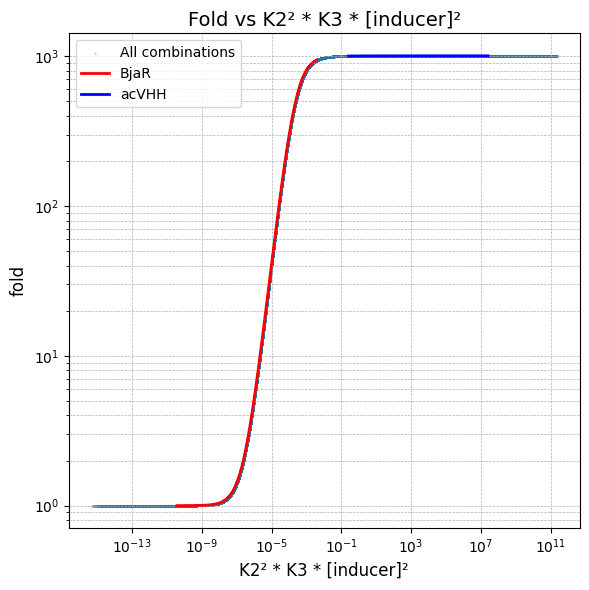

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# 变量范围（热图部分）
I_vals = np.logspace(-2, 1, 200)        # I: 0.01 ~ 10
k2_vals = np.logspace(-5, 3.5, 100)     # k2: 1e-5 ~ 3e3
k3_vals = np.linspace(0.05, 225, 100)   # k3: 0.05 ~ 225

# 网格组合所有变量
I_grid, k2_grid, k3_grid = np.meshgrid(I_vals, k2_vals, k3_vals, indexing='ij')

# 常量
Imax = 35.84931505
I0 = 0.035485714
k1 = 0.387876109
L = 10
kd = 40.97704697

# 固定项
x1 = np.sqrt(1 + 8 * L * k1)
F1 = np.log(L/2) + np.log((x1 - 1)/(x1 + 1)) + np.log(kd)
P1 = (Imax / (1 + np.exp(-F1))) + I0

# 激活项 & fold for scatter plot
m_grid = I_grid**2 * k2_grid**2 * k3_grid
x2_grid = np.sqrt(1 + 8 * L * m_grid)
F2_grid = np.log(L/2) + np.log((x2_grid - 1)/(x2_grid + 1)) + np.log(kd)
P2_grid = (Imax / (1 + np.exp(-F2_grid))) + I0
fold_grid = P2_grid / I0

# 散点图数据处理
x_axis_all = m_grid.flatten()
fold_vals_all = fold_grid.flatten()
mask = (~np.isnan(fold_vals_all)) & (fold_vals_all > 0) & (x_axis_all > 0)
x_axis_all = x_axis_all[mask]
fold_vals_all = fold_vals_all[mask]

# ---------- 单变量曲线部分（BjaR & acVHH） ----------
I_curve = np.logspace(-2, 2, 500)

def compute_curve(I, k2, k3):
    m = I**2 * k2**2 * k3
    x2 = np.sqrt(1 + 8 * L * m)
    F2 = np.log(L/2) + np.log((x2 - 1)/(x2 + 1)) + np.log(kd)
    P2 = (Imax / (1 + np.exp(-F2))) + I0
    return P2 / I0, m

# BjaR
fold_bja, x_bja = compute_curve(I_curve, 0.002735345, 0.050865889)

# acVHH
fold_acvhh, x_acvhh = compute_curve(I_curve, 58.84004211, 0.746886849)

# ---------- 绘图 ----------
plt.figure(figsize=(6, 6))

# 散点热图
plt.scatter(x_axis_all, fold_vals_all, s=1, alpha=0.2, label='All combinations')

# 两条特定曲线
plt.plot(x_bja, fold_bja, label='BjaR', color='red', linewidth=2)
plt.plot(x_acvhh, fold_acvhh, label='acVHH', color='blue', linewidth=2)

# 设置坐标轴
plt.xscale("log")
plt.yscale("log")
plt.xlabel("K2² * K3 * [inducer]²", fontsize=12)
plt.ylabel("fold", fontsize=12)
plt.title("Fold vs K2² * K3 * [inducer]²", fontsize=14)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7332\1880251647.py:29: RuntimeWarning: divide by zero encountered in log
  F1=np.log(L/2)+np.log((x1-(1))/(x1+(1)))+np.log(kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7332\1880251647.py:30: RuntimeWarning: divide by zero encountered in log
  F2=np.log(L/2)+np.log((x2-(1))/(x2+(1)))+np.log(kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7332\1880251647.py:36: RuntimeWarning: divide by zero encountered in divide
  fold=((1/y)*(L/2)*kd)/(1+(L/2)*kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7332\1880251647.py:36: RuntimeWarning: invalid value encountered in multiply
  fold=((1/y)*(L/2)*kd)/(1+(L/2)*kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7332\1880251647.py:45: RuntimeWarning: divide by zero encountered in log
  F1_acVHH = np.log(L/2) + np.log((x1_acVHH - 1) / (x1_acVHH + 1)) + np.log(kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7332\1880251647.py:46: RuntimeWarning: divide by zero encountered in log
  F2_acVHH 

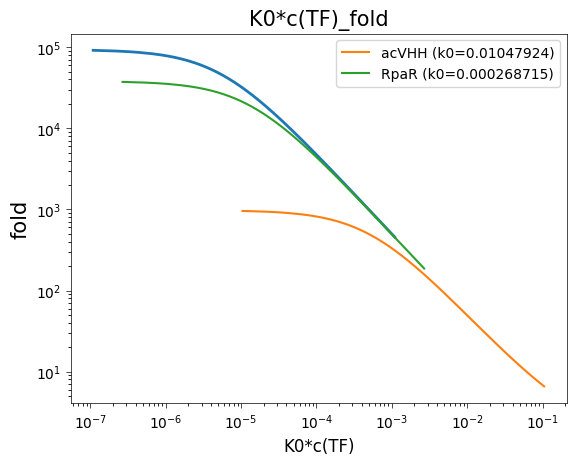

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd

# 设置x和y的坐标范围
L= np.arange(0,10,0.001)
k1= np.arange(0.000109651,0.387876109)
Imax=35.84931505

I0=0.035485714

I=10
k2=0.256016091

k3=225.0817618
m=k2*k2*k3*I*I
Imax=35.84931505
I0=0.111188222


M=1000

kd=40.97704697
x1 = np.sqrt(1+ 8 * L * (M*M*k1)) 
x2 = np.sqrt((1)*(1)+ 8 * L * (k1)) 
F1=np.log(L/2)+np.log((x1-(1))/(x1+(1)))+np.log(kd)
F2=np.log(L/2)+np.log((x2-(1))/(x2+(1)))+np.log(kd)
y=(x2-1)/(x2+1)

P1=(Imax/(1+np.exp(-F1)))+I0
P2=(Imax/(1+np.exp(-F2)))+I0

fold=((1/y)*(L/2)*kd)/(1+(L/2)*kd)

# Specific examples for acVHH and RpaR
k1_acVHH = 0.01047924
k1_RpaR = 0.000268715

# Calculate the fold values for these specific k1 values
x1_acVHH = np.sqrt(1 + 8 * L * (M*M*k1_acVHH))
x2_acVHH = np.sqrt(1 + 8 * L * k1_acVHH)
F1_acVHH = np.log(L/2) + np.log((x1_acVHH - 1) / (x1_acVHH + 1)) + np.log(kd)
F2_acVHH = np.log(L/2) + np.log((x2_acVHH - 1) / (x2_acVHH + 1)) + np.log(kd)
y_acVHH = (x2_acVHH - 1) / (x2_acVHH + 1)
fold_acVHH = ((1 / y_acVHH) * (L/2) * kd) / (1 + (L/2) * kd)

x1_RpaR = np.sqrt(1 + 8 * L * (M*M*k1_RpaR))
x2_RpaR = np.sqrt(1 + 8 * L * k1_RpaR)
F1_RpaR = np.log(L/2) + np.log((x1_RpaR - 1) / (x1_RpaR + 1)) + np.log(kd)
F2_RpaR = np.log(L/2) + np.log((x2_RpaR - 1) / (x2_RpaR + 1)) + np.log(kd)
y_RpaR = (x2_RpaR - 1) / (x2_RpaR + 1)
fold_RpaR = ((1 / y_RpaR) * (L/2) * kd) / (1 + (L/2) * kd)

# Plot the main curve
fig, ax = plt.subplots()
ax.plot(L*k1, fold, linewidth=2)

# Plot the specific examples as points
ax.plot(L *k1_acVHH, fold_acVHH,  label="acVHH (k0=0.01047924)")
ax.plot(L *k1_RpaR, fold_RpaR, label="RpaR (k0=0.000268715)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("K0*c(TF)", fontsize=12)
ax.set_ylabel("fold", fontsize=15)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5, labelsize=10)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'

# Add legend and title
plt.title('K0*c(TF)_fold', fontsize=15)
ax.legend()

# Show plot
plt.show()


C:\Users\Chestnut\AppData\Local\Temp\ipykernel_21224\4261773164.py:42: RuntimeWarning: invalid value encountered in log
  F1 = np.log(L / 2) + np.log((x1 - (kx1 + 1)) / (x1 + (kx1 + 1))) + np.log(kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_21224\4261773164.py:43: RuntimeWarning: divide by zero encountered in log
  F2 = np.log(L / 2) + np.log((x2 - (kx1 + 1)) / (x2 + (kx1 + 1))) + np.log(kd)


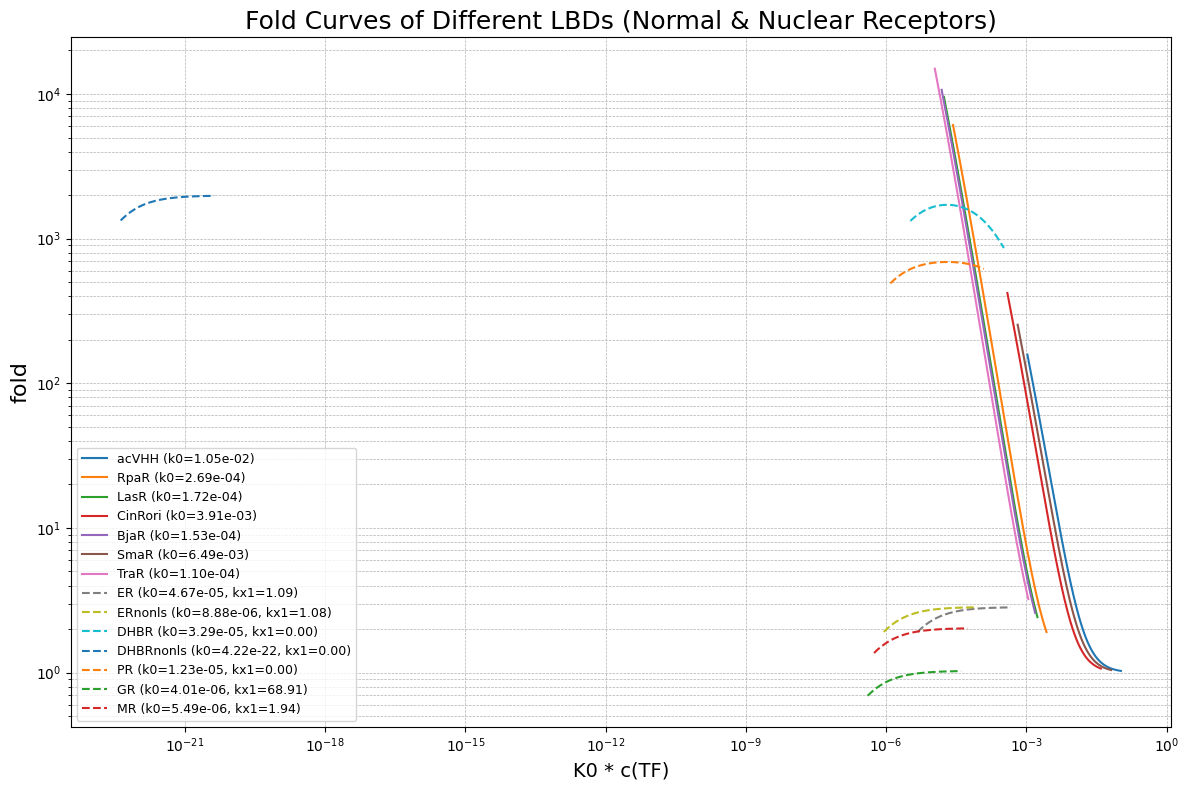

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 公共参数
L = np.arange(0.1, 10, 0.001)
M = 1000
kd = 40.97704697
Imax = 35.84931505  # 公式中需要用到
I0 = 0.111188222    # 公式中需要用到

# 普通LBD对应的k1
sensor_k1_normal = {
    "acVHH": 0.01047924,
    "RpaR": 0.000268715,
    "LasR": 0.000171923,
    "CinRori": 0.003906623,
    "BjaR": 0.00015346,
    "SmaR": 0.006491885,
    "TraR": 0.000109651
}

# 核受体对应的k1和kx1
sensor_k1_nuclear = {
    "ER": (4.67083E-05, 1.086833596),
    "ERnonls": (8.88E-06, 1.084513068),
    "DHBR": (3.2879E-05, 0.001001405),
    "DHBRnonls": (4.21691E-22, 0.001007507),
    "PR": (1.22917E-05, 0.00273789),
    "GR": (4.01E-06, 68.91003389),
    "MR": (5.49128E-06, 1.937182665)
}

def fold_normal(L, k1, M, kd):
    x2 = np.sqrt(1 + 8 * L * k1)
    y = (x2 - 1) / (x2 + 1)
    fold = ((1 / y) + (L / 2) * kd) / (1 + (L / 2) * kd)
    return fold

def fold_nuclear(L, k1, kx1, M, kd, Imax, I0):
    x1 = np.sqrt(1 + kx1 + 8 * L * (M * M * (k1 + k1 * kx1 * kx1)))
    x2 = np.sqrt(( kx1 + 1) ** 2 + 8 * L * ( k1 + k1 * kx1 * kx1 ))
    F1 = np.log(L / 2) + np.log((x1 - (kx1 + 1)) / (x1 + (kx1 + 1))) + np.log(kd)
    F2 = np.log(L / 2) + np.log((x2 - (kx1 + 1)) / (x2 + (kx1 + 1))) + np.log(kd)
    y = (x2 - 1) / (x2 + 1)
    P1 = (Imax / (1 + np.exp(-F1))) + I0
    P2 = (Imax / (1 + np.exp(-F2))) + I0
    fold = ((1 / y) * (L / 2) * kd) / (1 + (L / 2) * kd)
    return fold

plt.figure(figsize=(12, 8))

# 画普通LBD
for name, k1 in sensor_k1_normal.items():
    fold = fold_normal(L, k1, M, kd)
    fold = np.clip(fold, 1e-10, None)  # 防止log(0)报错
    plt.plot(L * k1, fold, label=f"{name} (k0={k1:.2e})")

# 画核受体LBD
for name, (k1, kx1) in sensor_k1_nuclear.items():
    fold = fold_nuclear(L, k1, kx1, M, kd, Imax, I0)
    fold = np.clip(fold, 1e-10, None)
    plt.plot(L * k1, fold, label=f"{name} (k0={k1:.2e}, kx1={kx1:.2f})", linestyle='--')

plt.xscale("log")
plt.yscale("log")
plt.xlabel("K0 * c(TF)", fontsize=14)
plt.ylabel("fold", fontsize=16)
plt.title("Fold Curves of Different LBDs (Normal & Nuclear Receptors)", fontsize=18)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend(fontsize=9, loc='best')
plt.tight_layout()

plt.savefig("fold_curves_all_LBDs_with_nuclear.svg", format="svg")
plt.show()


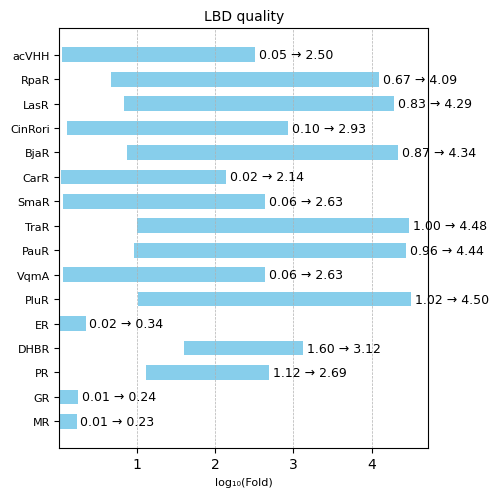

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# 避免 log 错误
L = np.arange(0.1, 10, 0.001)
kd =10

# k1 值
sensor_k1 = {
    "acVHH": 0.01047924,
    "RpaR": 0.000268715,
    "LasR": 0.000171923,
    "CinRori": 0.003906623,
    "BjaR": 0.000153468,   # 修正
    "CarR": 0.024643659,   # 修正
    "SmaR": 0.007799755,   # 修正
    "TraR": 0.000109651,
    "PauR": 0.00012233,
    "VqmA": 0.007756991,
    "PluR": 0.000105019,
    "ER": 6.353E-12,       # 修正
    "DHBR": 4.21691E-22,
    "PR": 1.22917E-05,
    "GR": 7.3034E-06,      # 修正
    "MR": 5.49128E-06
}


# === kx1 参数（来自表格） ===
nuclear_kx1 = {
    "ER": 1.112792988,         # 修正
    "DHBR": 0.001007507,
    "PR": 0.00273789,
    "GR": 1.776378776493321,   # 修正
    "MR": 1.937182665
}


def compute_log_fold_range(L, k1, kd, is_nuclear=False, kx1=0):
    if is_nuclear:
        k1_eff = k1 + k1 * kx1 * kx1
        
        x2 = np.sqrt((1 + kx1)**2 + 8 * L * k1_eff)
    else:
        x2 = np.sqrt(1 + 8 * L * k1)
    y = (x2 - 1) / (x2 + 1)
    fold = ((1 / y) + (L / 2) * kd) / (1 + (L / 2) * kd)
    fold = np.nan_to_num(fold, nan=1e-6, posinf=1e6, neginf=1e-6)
    fold = fold[fold > 0]
    if len(fold) == 0:
        return (0, 0)
    return np.log10(np.min(fold)), np.log10(np.max(fold))

labels = []
mins_log = []
heights_log = []

for name, k1 in sensor_k1.items():
    is_nuclear = name in nuclear_kx1
    kx1 = nuclear_kx1.get(name, 0)
    min_log, max_log = compute_log_fold_range(L, k1, kd, is_nuclear=is_nuclear, kx1=kx1)
    labels.append(name)
    mins_log.append(min_log)
    heights_log.append(max_log - min_log)

# 画图
fig, ax = plt.subplots(figsize=(5.08, 5.08))
y_pos = np.arange(len(labels))
bar_height = 0.6

bars = ax.barh(y_pos, width=heights_log, left=mins_log, height=bar_height, color='skyblue')

ax.set_xlabel('log₁₀(Fold)', fontsize=8)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title('LBD quality', fontsize=10)
ax.invert_yaxis()

# 添加标签
for i, bar in enumerate(bars):
    left = mins_log[i]
    right = left + heights_log[i]
    ax.text(right + 0.05, bar.get_y() + bar.get_height()/2,
            f"{left:.2f} → {right:.2f}", va='center', fontsize=9)

plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.tight_layout()

# 保存为SVG文件（可选）
plt.savefig("E:/Desktop/LBD_quality.svg", format='svg')

plt.show()


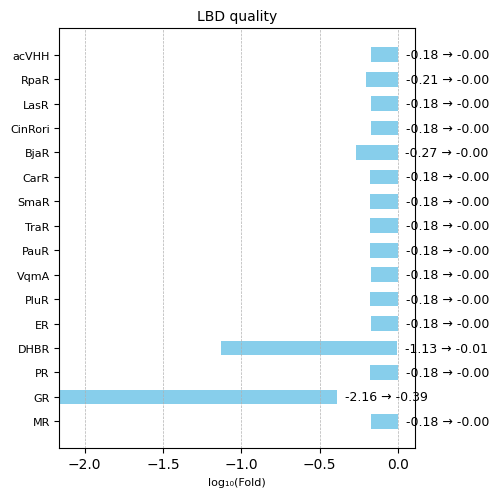

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 避免 log 错误
L = np.arange(0.1, 10, 0.001)
kd = 40
I = 1000

# === k1 参数（来自表格） ===
sensor_k1 = {
    "acVHH": 0.01047924,
    "RpaR": 0.000268715,
    "LasR": 0.000171923,
    "CinRori": 0.003906623,
    "BjaR": 0.000153468,   # 修正
    "CarR": 0.024643659,   # 修正
    "SmaR": 0.007799755,   # 修正
    "TraR": 0.000109651,
    "PauR": 0.00012233,
    "VqmA": 0.007756991,
    "PluR": 0.000105019,
    "ER": 6.353E-12,       # 修正
    "DHBR": 4.21691E-22,
    "PR": 1.22917E-05,
    "GR": 7.3034E-06,      # 修正
    "MR": 5.49128E-06
}

# === k2 参数（来自表格） ===
sensor_k2 = {
    "acVHH": 58.84004211,
    "RpaR": 0.007083518,
    "LasR": 0.256016091,
    "CinRori": 56.83673859,
    "BjaR": 0.002735345,
    "CarR": 8.49165E-06,   # 修正
    "SmaR": 0.218537966,
    "TraR": 0.181526351,
    "PauR": 1.751281238,
    "VqmA": 32.64533058,
    "PluR": 0.455405602,
    "ER": 3.583382137,
    "DHBR": 0.039590602,
    "PR": 0.462590457,
    "GR": 0.00361846,
    "MR": 2.00561142
}

# === k3 参数（来自表格） ===
sensor_k3 = {
    "acVHH": 0.746886849,
    "RpaR": 0.760771692,
    "LasR": 225.0817618,
    "CinRori": 0.162220061,
    "BjaR": 0.050865889,
    "CarR": 538352547.7,
    "SmaR": 0.042606588,
    "TraR": 0.060416246,
    "PauR": 0.000427387,
    "VqmA": 0.020473023,
    "PluR": 0.000175967,
    "ER": 4.130148252,
    "DHBR": 13.17104327,
    "PR": 0.074821866,
    "GR": 0.000937889,
    "MR": 0.001243206
}

# === kx1 参数（来自表格） ===
nuclear_kx1 = {
    "ER": 1.112792988,         # 修正
    "DHBR": 0.001007507,
    "PR": 0.00273789,
    "GR": 1.776378776493321,   # 修正
    "MR": 1.937182665
}

# === kx2 参数（来自表格） ===
nuclear_kx2 = {
    "ER": 4.960066803,
    "DHBR": 0.001604871,
    "PR": 0.921262549,
    "GR": 0.001928521,
    "MR": 1.619613647
}

def compute_log_fold_range(L, k2, k3, kd, I, is_nuclear=False, kx2=0):
    if is_nuclear:
        k1_eff = k1 + k1 * kx1 * kx1
        x1 = np.sqrt((1 + kx1)**2 + 8 * L * k1_eff)
        x2 = np.sqrt((kx2 * k2 * I + 1) ** 2 + 8 * L * (k3 * k2 * k2 * kx2 * kx2 * I * I))
    else:
        x2 = np.sqrt((k2 * I + 1) ** 2 + 8 * L * (k2 * k2 * k3 * I * I))
        x1 = np.sqrt(1 + 8 * L * k1)
    y1 = (x1 - 1) / (x1 + 1)
    y2 = (x2 - 1) / (x2 + 1)
    fold = ( (L / 2) * kd) / ((1 / y2) + (L / 2) * kd)
    fold = np.nan_to_num(fold, nan=1e-6, posinf=1e6, neginf=1e-6)
    fold = fold[fold > 0]
    if len(fold) == 0:
        return (0, 0)
    return np.log10(np.min(fold)), np.log10(np.max(fold))

labels, mins_log, heights_log = [], [], []

for name, k1 in sensor_k1.items():
    k2 = sensor_k2[name]
    k3 = sensor_k3[name]
    is_nuclear = name in nuclear_kx1
    kx1 = nuclear_kx1.get(name, 0)
    kx2 = nuclear_kx2.get(name, 0)
    min_log, max_log = compute_log_fold_range(L, k2, k3, kd, I,
                                              is_nuclear=is_nuclear, kx2=kx2)
    labels.append(name)
    mins_log.append(min_log)
    heights_log.append(max_log - min_log)

# 画图
fig, ax = plt.subplots(figsize=(5.08, 5.08))
y_pos = np.arange(len(labels))
bars = ax.barh(y_pos, width=heights_log, left=mins_log, height=0.6, color='skyblue')

ax.set_xlabel('log₁₀(Fold)', fontsize=8)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title('LBD quality', fontsize=10)
ax.invert_yaxis()

for i, bar in enumerate(bars):
    left = mins_log[i]
    right = left + heights_log[i]
    ax.text(right + 0.05, bar.get_y() + bar.get_height()/2,
            f"{left:.2f} → {right:.2f}", va='center', fontsize=9)

plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("E:/Desktop/LBD_quality.svg", format='svg')
plt.show()


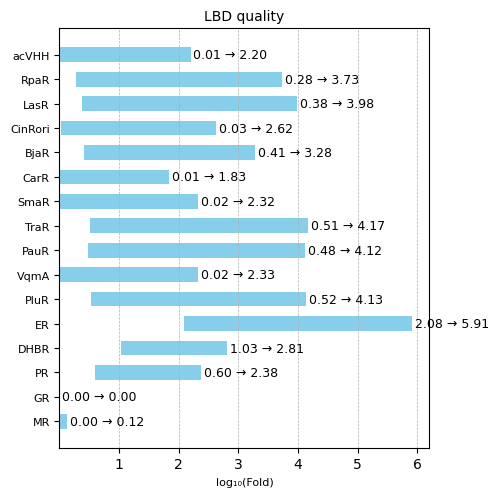

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# 避免 log 错误
L = np.arange(0.1, 10, 0.001)
kd = 40.97704697

# === k1 参数（来自表格） ===
sensor_k1 = {
    "acVHH": 0.01047924,
    "RpaR": 0.000268715,
    "LasR": 0.000171923,
    "CinRori": 0.003906623,
    "BjaR": 0.000153468,   
    "CarR": 0.024643659,   
    "SmaR": 0.007799755,   
    "TraR": 0.000109651,
    "PauR": 0.00012233,
    "VqmA": 0.007756991,
    "PluR": 0.000105019,
    "ER": 0.000002016960627,       # 修正
    "DHBR": 4.21691E-22,
    "PR": 1.22917E-05,
    "GR": 0.000003901059096,      # 修正
    "MR": 0.000003043266786       # 修正
}


# === k2 参数（来自表格） ===
sensor_k2 = {
    "acVHH": 58.84004211,
    "RpaR": 0.007083518,
    "LasR": 0.256016091,
    "CinRori": 56.83673859,
    "BjaR": 0.002735345,
    "CarR": 8.49165E-06,   # 修正
    "SmaR": 0.218537966,
    "TraR": 0.181526351,
    "PauR": 1.751281238,
    "VqmA": 32.64533058,
    "PluR": 0.455405602,
    "ER":  15.591256628348091,   # 修正
    "DHBR": 0.039590602,
    "PR": 0.462590457,
    "GR": 0.035170104659471, # 修正
    "MR": 2.00561142  # 修正
}

# === k3 参数（来自表格） ===
sensor_k3 = {
    "acVHH": 0.746886849,
    "RpaR": 0.760771692,
    "LasR": 225.0817618,
    "CinRori": 0.162220061,
    "BjaR": 0.050865889,
    "CarR": 538352547.7,
    "SmaR": 0.042606588,
    "TraR": 0.060416246,
    "PauR": 0.000427387,
    "VqmA": 0.020473023,
    "PluR": 0.000175967,
    "ER": 1.700406357783870,
    "DHBR": 13.17104327,
    "PR": 0.074821866,
    "GR": 0.000020954379849,   # 修正
    "MR": 0.001243206           # 修正
}


# === kx1 参数（来自表格） ===
nuclear_kx1 = {
    #"ER": 0.798527188158513,         # 修正
    "DHBR": 0.001007507,
    "PR": 0.00273789,
    "GR": 1.776378776493321,   # 修正
    "MR": 1.937182665
}

# === kx2 参数（来自表格） ===
nuclear_kx2 = {
    #"ER": 0.191861964654868,
    "DHBR": 0.001604871,
    "PR": 0.921262549,
    "GR": 0.001928521,
    "MR": 1.619613647
}

sensor_I = {
    "acVHH": 1,
    "RpaR": 1000,
    "LasR": 10,
    "CinRori": 1,
    "BjaR": 100,
    "SmaR": 1,
    "TraR": 1,
    "CarR": 1,
    "PauR": 10,
    "PluR": 100,
    "VqmA": 100,
    "CepR": 100,
    "ER": 0.1,
    "DHBR": 1000,
    "PR": 100,
    "GR": 100,
    "MR": 1,
}

def compute_log_fold_range(L, k1, k2, k3, kd, I, is_nuclear=False, kx1=0, kx2=0):
    if is_nuclear:
        k1_eff = k1 + k1 * kx1 * kx1
        x1 = np.sqrt((1 + kx1)**2 + 8 * L * k1_eff)
        x2 = np.sqrt((1 + kx1)**2 + 8 * L * ( k2 * k2 * k3 * I * I +k3 * k2 * k2 * kx2 * kx2 * I * I))
    else:
        x2 = np.sqrt(1 + 8 * L * (k2 * k2 * k3 * I * I))
        x1 = np.sqrt(1 + 8 * L * k1)
    y1 = (x1 - 1) / (x1 + 1)
    y2 = (x2 - 1) / (x2 + 1)
    fold = ((1 / y1) + (L / 2) * kd) / ((1 / y2) + (L / 2) * kd)
    fold = np.nan_to_num(fold, nan=1e-6, posinf=1e6, neginf=1e-6)
    fold = fold[fold > 0]
    if len(fold) == 0:
        return (0, 0)
    return np.log10(np.min(fold)), np.log10(np.max(fold))

labels, mins_log, heights_log = [], [], []

for name, k1 in sensor_k1.items():
    k2 = sensor_k2[name]
    k3 = sensor_k3[name]
    is_nuclear = name in nuclear_kx1
    kx1 = nuclear_kx1.get(name, 0)
    kx2 = nuclear_kx2.get(name, 0)
    min_log, max_log = compute_log_fold_range(L, k1, k2, k3, kd, I,
                                              is_nuclear=is_nuclear, kx1=kx1, kx2=kx2)
    labels.append(name)
    mins_log.append(min_log)
    heights_log.append(max_log - min_log)

# 画图
fig, ax = plt.subplots(figsize=(5.08, 5.08))
y_pos = np.arange(len(labels))
bars = ax.barh(y_pos, width=heights_log, left=mins_log, height=0.6, color='skyblue')

ax.set_xlabel('log₁₀(Fold)', fontsize=8)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title('LBD quality', fontsize=10)
ax.invert_yaxis()

for i, bar in enumerate(bars):
    left = mins_log[i]
    right = left + heights_log[i]
    ax.text(right + 0.05, bar.get_y() + bar.get_height()/2,
            f"{left:.2f} → {right:.2f}", va='center', fontsize=9)

plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("E:/Desktop/LBD_quality.svg", format='svg')
plt.show()


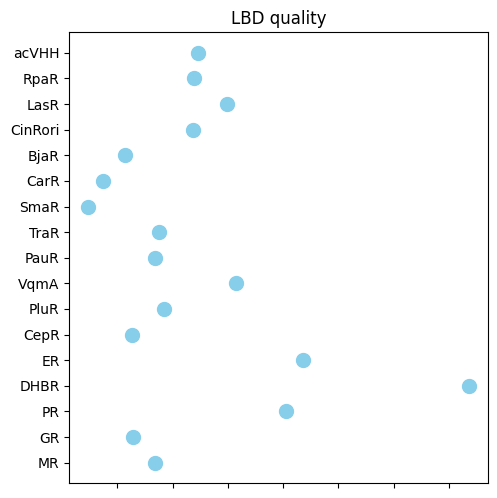

传感器比值计算结果:
acVHH: 2.47e+05
RpaR: 1.42e+05
LasR: 8.58e+06
CinRori: 1.34e+05
BjaR: 2.48e+01
CarR: 1.58e+00
SmaR: 2.61e-01
TraR: 1.82e+03
PauR: 1.07e+03
VqmA: 2.81e+07
PluR: 3.48e+03
CepR: 5.92e+01
ER: 1.18e+11
DHBR: 1.24e+20
PR: 1.47e+10
GR: 6.64e+01
MR: 1.15e+03
结果已保存到 E:/Desktop/LBD_quality_k3k1.csv


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# === k1 参数（来自表格） ===
sensor_k1 = {
    "acVHH": 0.01047924,
    "RpaR": 0.000268715,
    "LasR": 0.000171923,
    "CinRori": 0.003906623,
    "BjaR": 0.000153468,   
    "CarR": 0.024643659,   
    "SmaR": 0.007799755,   
    "TraR": 0.000109651,
    "PauR": 0.00012233,
    "VqmA": 0.007756991,
    "PluR": 0.000105019,
    "CepR":0.056863842,
    "ER": 0.000002016960627,
    "DHBR": 4.21691E-22,
    "PR": 1.22917E-05,
    "GR": 3.90104E-06,
    "MR": 0.000003043266786
}

# === k2 参数（来自表格） ===
sensor_k2 = {
    "acVHH": 58.84004211,
    "RpaR": 0.007083518,
    "LasR": 0.256016091,
    "CinRori": 56.83673859,
    "BjaR": 0.002735345,
    "CarR": 8.49165E-06,
    "SmaR": 0.218537966,
    "TraR": 0.181526351,
    "PauR": 1.751281238,
    "VqmA": 32.64533058,
    "PluR": 0.455405602,
    "CepR":0.028953126,
    "ER": 15.591256628348091,
    "DHBR": 0.039590602,
    "PR": 0.462590457,
    "GR": 0.035169106,
    "MR": 2.00561142
}

# === k3 参数（来自表格） ===
sensor_k3 = {
    "acVHH": 0.746886849,
    "RpaR": 0.760771692,
    "LasR": 225.0817618,
    "CinRori": 0.162220061,
    "BjaR": 0.050865889,
    "CarR": 538352547.7,
    "SmaR": 0.042606588,
    "TraR": 0.060416246,
    "PauR": 0.000427387,
    "VqmA": 0.020473023,
    "PluR": 0.000175967,
    "CepR":0.401875242,
    "ER": 1.700406357783870,
    "DHBR": 13.17104327,
    "PR": 0.074821866,
    "GR": 2.09547E-05,
    "MR": 0.001243206
}

# === I 参数（来自表格） ===
sensor_I = {
    "acVHH": 1,
    "RpaR": 1000,
    "LasR": 10,
    "CinRori": 1,
    "BjaR": 100,
    "SmaR": 1,
    "TraR": 10,
    "CarR": 1,
    "PauR": 10,
    "PluR": 100,
    "VqmA": 100,
    "CepR":100,
    "ER": 100,
    "DHBR": 1,
    "PR": 10,
    "GR": 100,
    "MR": 1,
}

# === kx1 参数（来自表格） ===
nuclear_kx1 = {
    "ER": 0.798527188158513,         # 修正
    "DHBR": 0.001007507,
    "PR": 0.00273789,
    #"GR": 1.776378776493321,   # 修正
    "MR": 1.937182665
}

# === kx2 参数（来自表格） ===
nuclear_kx2 = {
    "ER": 0.191861964654868,
    "DHBR": 0.001604871,
    "PR": 0.921262549,
    #"GR": 0.001928521,
    "MR": 1.619613647
}
def compute_ratio(name, k1, k2, k3, I):
    # 检查是否为核受体
    if name in nuclear_kx1 and name in nuclear_kx2:
        kx1 = nuclear_kx1[name]
        kx2 = nuclear_kx2[name]
        # 核受体公式: k3 * k2^2 * kx2^2 * I^2 / (k1 * kx1^2)
        return (k3 * k2**2 * kx2**2 * I**2) / (k1 * kx1**2)
    else:
        # 普通传感器公式: k3 * k2^2 * I^2 / k1
        return (k3 * k2**2 * I**2) / k1

# 存储数据
labels, ratios = [], []

# 遍历所有传感器，计算比值
for name in sensor_k1.keys():
    if name in sensor_k2 and name in sensor_k3 and name in sensor_I:
        k1 = sensor_k1[name]
        k2 = sensor_k2[name]
        k3 = sensor_k3[name]
        I = sensor_I[name]
        ratio = compute_ratio(name, k1, k2, k3, I)
        labels.append(name)
        ratios.append(ratio)
    else:
        print(f"警告: 传感器 {name} 缺少必要的参数")

# 绘制图表 - 只显示点
fig, ax = plt.subplots(figsize=(5.08, 5.08))
y_pos = np.arange(len(labels))

# 使用散点图代替条形图，只显示点
ax.scatter(ratios, y_pos, color='skyblue', s=100)  # s参数控制点的大小

# 设置图表标签和标题
#ax.set_xlabel('LBD quality', fontsize=10)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_title('LBD quality', fontsize=12)
ax.invert_yaxis()  # 反转 y 轴，使得标签从上到下显示

# 设置x轴为对数尺度，因为比值范围很大
ax.set_xscale('log')

# 添加网格线以便更好地读取数值
#ax.grid(True, linestyle='--', alpha=0.7)
ax.set_xticklabels([])
ax.set_xlabel('') 
# 自动调整布局
plt.tight_layout()

# 保存图表为 SVG 格式
plt.savefig("E:/Desktop/LBD_quality_k3k1.svg", format='svg')

# 显示图表
plt.show()

# 打印所有计算结果
print("传感器比值计算结果:")
for i, name in enumerate(labels):
    print(f"{name}: {ratios[i]:.2e}")


# === 保存到 CSV ===
df = pd.DataFrame({
    "Sensor": labels,
    "Ratio": ratios
})

df.to_csv("E:/Desktop/LBD_quality_k3k1.csv", index=False)
print("结果已保存到 E:/Desktop/LBD_quality_k3k1.csv")

mamm

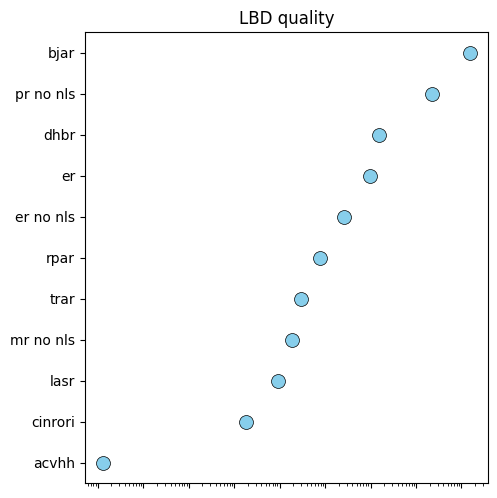

✅ 去重后的 LBD 结果已保存到: E:/Desktop/mamm/LBD_quality_unique.csv
✅ 图表已保存为: E:/Desktop/mamm/LBD_quality_unique.svg


In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 文件路径
input_csv = "E:/Desktop/mamm/output_analytical.csv"
output_csv = "E:/Desktop/mamm/LBD_quality_unique.csv"
output_plot = "E:/Desktop/mamm/LBD_quality_unique.svg"

# 读取 CSV
df = pd.read_csv(input_csv)

# === 提取 LBD ===
# 假设 ID 是 DBD-LBD 或只有 LBD，如果只想显示 LBD
df['LBD'] = df['ID'].apply(lambda x: x.split('-')[-1].strip().lower())

# 计算比值 R = k2_k3 * Imax_inducer^2 / k1
df['R'] = (df['k2_k3'] * df['Imax_inducer']**2) / df['k1']

# 按 LBD 去重并取平均
df_unique = df.groupby('LBD', as_index=False)['R'].mean()
df_unique.sort_values(by='R', ascending=False, inplace=True)

# 提取 labels 和 ratios
labels = df_unique['LBD'].tolist()
ratios = df_unique['R'].tolist()

# 绘图
fig, ax = plt.subplots(figsize=(5.08, 5.08))
y_pos = np.arange(len(labels))

ax.scatter(ratios, y_pos, color='skyblue', s=100, edgecolors='k', linewidths=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xscale('log')
ax.invert_yaxis()
ax.set_title('LBD quality', fontsize=12)
ax.set_xlabel('')
ax.set_xticklabels([])

plt.tight_layout()
plt.savefig(output_plot, format='svg')
plt.show()

# 保存 CSV
df_unique.to_csv(output_csv, index=False)
print(f"✅ 去重后的 LBD 结果已保存到: {output_csv}")
print(f"✅ 图表已保存为: {output_plot}")


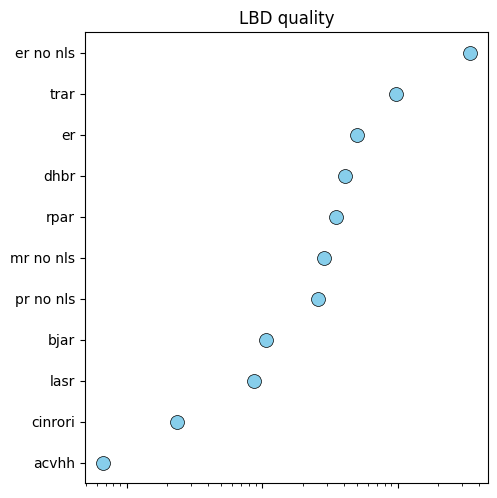

✅ 去重后的 LBD 结果已保存到: E:/Desktop/mamm/LBD_quality_unique.csv
✅ 图表已保存为: E:/Desktop/mamm/LBD_quality_unique.svg


In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 文件路径
input_csv = "E:/Desktop/mamm/params_shared.csv"
output_csv = "E:/Desktop/mamm/LBD_quality_unique.csv"
output_plot = "E:/Desktop/mamm/LBD_quality_unique.svg"

# 读取 CSV
df = pd.read_csv(input_csv)

# === 提取 LBD ===
# 假设 ID 是 DBD-LBD 或只有 LBD，如果只想显示 LBD
df['LBD'] = df['ID'].apply(lambda x: x.split('-')[-1].strip().lower())

# 计算比值 R = k2_k3 * Imax_inducer^2 / k1
df['R'] = (df['M'] * df['I']**2 )/ df['k1']

# 按 LBD 去重并取平均
df_unique = df.groupby('LBD', as_index=False)['R'].mean()
df_unique.sort_values(by='R', ascending=False, inplace=True)

# 提取 labels 和 ratios
labels = df_unique['LBD'].tolist()
ratios = df_unique['R'].tolist()

# 绘图
fig, ax = plt.subplots(figsize=(5.08, 5.08))
y_pos = np.arange(len(labels))

ax.scatter(ratios, y_pos, color='skyblue', s=100, edgecolors='k', linewidths=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xscale('log')
ax.invert_yaxis()
ax.set_title('LBD quality', fontsize=12)
ax.set_xlabel('')
ax.set_xticklabels([])

plt.tight_layout()
plt.savefig(output_plot, format='svg')
plt.show()

# 保存 CSV
df_unique.to_csv(output_csv, index=False)
print(f"✅ 去重后的 LBD 结果已保存到: {output_csv}")
print(f"✅ 图表已保存为: {output_plot}")


In [ ]:
import numpy as np
import pandas as pd

class QuickParameterEstimator:
    def __init__(self, Imax_promoter=2.5, L=1, k2k3_min=1e-6):
        self.Imax = Imax_promoter
        self.L = L
        self.k2k3_min = k2k3_min  # k2k3最小值

    def estimate_kd(self, P0, P01, I01=0.1):
        """用 P01 / P0 估算 kd"""
        epsilon = 1e-8
        S01 = (P01 - P0) / (self.Imax + epsilon)
        kd = 2 * S01 / self.L
        return max(kd, 0)

    def estimate_k1(self, P0, I0, kd):
        """用 P0 和 I0 估算 k1"""
        epsilon = 1e-8
        S0 = (P0 - I0) / (self.Imax - (P0 - I0) + epsilon)
        k1 = S0 / (self.L**2 * kd + epsilon)
        return max(k1, 0)

    def estimate_k2k3(self, P0, Pmax, k1, kd, I):
        """用 Pmax 估算 k2^2 * k3"""
        epsilon = 1e-8
        Smax = (Pmax - P0) / (self.Imax - (Pmax - P0) )
        k2k3 = Smax / (self.L**2 * kd * I**2 + epsilon) - k1 / (I**2)
        k2k3 = max(k2k3, self.k2k3_min)  # 最小值限制
        return k2k3

    def estimate_all(self, input_csv, output_csv):
        df = pd.read_csv(input_csv)

        # --- 自动生成 DBD 和 LBD 列，并统一格式 ---
        df['DBD'] = df['ID'].apply(lambda x: x.split('-')[0].strip().lower() if len(x.split('-'))>0 else 'unknown')
        df['LBD'] = df['ID'].apply(lambda x: x.split('-')[1].strip().lower() if len(x.split('-'))>1 else 'unknown')

        results = []

        # --- 先计算每个 DBD 的平均 Kd ---
        dbd_kd = {}
        for dbd, group in df.groupby('DBD'):
            kds = []
            for _, row in group.iterrows():
                try:
                    I01 = 0.1 * float(row['I'])
                    kd_i = self.estimate_kd(float(row['P0']), float(row['P01']), I01)
                    kds.append(kd_i)
                except:
                    continue
            dbd_kd[dbd] = np.mean(kds) if kds else 0.1

        # --- LBD 参数第一次出现时计算 ---
        lbd_params = {}

        # 遍历每行
        for _, row in df.iterrows():
            try:
                sensor_id = row['ID']
                DBD = row['DBD']
                LBD = row['LBD']

                P0 = float(row['P0'])
                P01 = float(row['P01'])
                Pmax = float(row['Pmax'])
                I0 = float(row['I0'])              # 从 CSV 读取 I0
                Imax_inducer = float(row['I'])
                I01 = 0.1 * Imax_inducer

                # --- Kd 直接用 DBD 平均值 ---
                kd = dbd_kd.get(DBD, 0.1)

                # --- k1, k2k3 按 LBD 共用 ---
                if LBD not in lbd_params:
                    k1 = self.estimate_k1(P0, I0, kd)
                    k2k3 = self.estimate_k2k3(P0, Pmax, k1, kd, Imax_inducer)
                    lbd_params[LBD] = (k1, k2k3)
                else:
                    k1, k2k3 = lbd_params[LBD]

                results.append({
                    'ID': sensor_id,
                    'DBD': DBD,
                    'LBD': LBD,
                    'Kd': kd,
                    'k1': k1,
                    'k2_k3': k2k3,
                    'I0': I0,
                    'Imax_inducer': Imax_inducer
                })

            except Exception as e:
                print(f"⚠️ Error with sensor {row.get('ID','unknown')}: {e}")
                results.append({
                    'ID': row.get('ID','unknown'),
                    'DBD': row.get('DBD','unknown'),
                    'LBD': row.get('LBD','unknown'),
                    'Kd': np.nan,
                    'k1': np.nan,
                    'k2_k3': np.nan,
                    'I0': np.nan,
                    'Imax_inducer': np.nan
                })

        out_df = pd.DataFrame(results)
        out_df.to_csv(output_csv, index=False)
        print(f"✅ Quick parameter estimates saved to: {output_csv}")


# ---------------- Example usage ----------------
if __name__ == "__main__":
    estimator = QuickParameterEstimator(Imax_promoter=2.5, L=1, k2k3_min=1e-6)
    estimator.estimate_all(
        input_csv="E:/Desktop/mamm/estimate.csv",
        output_csv="E:/Desktop/mamm/output_quick.csv"
    )


✅ Quick parameter estimates saved to: E:/Desktop/mamm/output_quick.csv


核受体

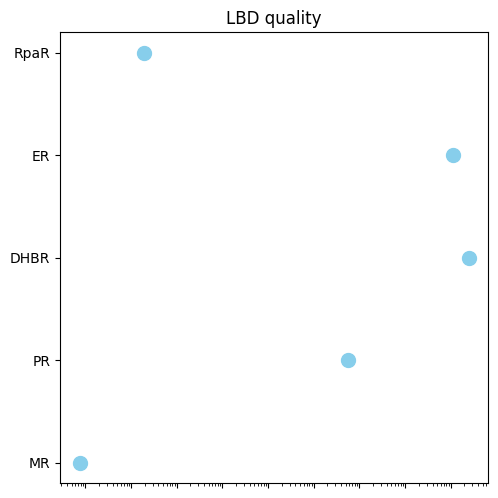

传感器比值计算结果:
RpaR: 1.91e+04
ER: 1.10e+11
DHBR: 2.46e+11
PR: 5.74e+08
MR: 7.47e+02
结果已保存到 E:/Desktop/LBD_quality_k3k1.csv


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# === k1 参数（来自表格） ===
sensor_k1 = {
    "RpaR": 0.000421789,
    "ER": 5.93003E-09,
    "DHBR": 4.68825E-10,
    "PR": 0.000196,
    "MR": 0.000112384
}

# === k2 参数（来自表格） ===
sensor_k2 = {
    "RpaR": 0.001582173,
    "ER": 0.325774887,
    "DHBR": 0.81679679,
    "PR": 0.00028,
    "MR": 400.5834895
}

# === k3 参数（来自表格） ===
sensor_k3 = {
    "RpaR": 80.39233398,
    "ER": 5229.70458,
    "DHBR": 1.08611216,
    "PR": 97651.80276,
    "MR": 0.024894813
}

# === I 参数（来自表格） ===
sensor_I = {
    "RpaR":200,
    "ER": 0.01,
    "DHBR": 100,
    "PR": 0.1,
    "MR": 1,
}

# === kx1 参数（来自表格） ===
nuclear_kx1 = {
    "ER": 0.303218487,         # 修正
    "DHBR": 0.895304788,
    "PR": 0.211319,   
    "MR": 13.60910816
}

# === kx2 参数（来自表格） ===
nuclear_kx2 = {
    "ER": 32.90477082,
    "DHBR": 0.113015736,
    "PR": 8103.343332,
    "MR": 0.062385854
}
def compute_ratio(name, k1, k2, k3, I):
    # 检查是否为核受体
    if name in nuclear_kx1 and name in nuclear_kx2:
        kx1 = nuclear_kx1[name]
        kx2 = nuclear_kx2[name]
        # 核受体公式: k3 * k2^2 * kx2^2 * I^2 / (k1 * kx1^2)
        return (k3 * k2**2 * kx2**2 * I**2) / (k1 * kx1**2)
    else:
        # 普通传感器公式: k3 * k2^2 * I^2 / k1
        return (k3 * k2**2 * I**2) / k1

# 存储数据
labels, ratios = [], []

# 遍历所有传感器，计算比值
for name in sensor_k1.keys():
    if name in sensor_k2 and name in sensor_k3 and name in sensor_I:
        k1 = sensor_k1[name]
        k2 = sensor_k2[name]
        k3 = sensor_k3[name]
        I = sensor_I[name]
        ratio = compute_ratio(name, k1, k2, k3, I)
        labels.append(name)
        ratios.append(ratio)
    else:
        print(f"警告: 传感器 {name} 缺少必要的参数")

# 绘制图表 - 只显示点
fig, ax = plt.subplots(figsize=(5.08, 5.08))
y_pos = np.arange(len(labels))

# 使用散点图代替条形图，只显示点
ax.scatter(ratios, y_pos, color='skyblue', s=100)  # s参数控制点的大小

# 设置图表标签和标题
#ax.set_xlabel('LBD quality', fontsize=10)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_title('LBD quality', fontsize=12)
ax.invert_yaxis()  # 反转 y 轴，使得标签从上到下显示

# 设置x轴为对数尺度，因为比值范围很大
ax.set_xscale('log')

# 添加网格线以便更好地读取数值
#ax.grid(True, linestyle='--', alpha=0.7)
ax.set_xticklabels([])
ax.set_xlabel('') 
# 自动调整布局
plt.tight_layout()

# 保存图表为 SVG 格式
plt.savefig("E:/Desktop/mamm/LBD_quality_k3k1.svg", format='svg')

# 显示图表
plt.show()

# 打印所有计算结果
print("传感器比值计算结果:")
for i, name in enumerate(labels):
    print(f"{name}: {ratios[i]:.2e}")


# === 保存到 CSV ===
df = pd.DataFrame({
    "Sensor": labels,
    "Ratio": ratios
})

df.to_csv("E:/Desktop/LBD_quality_k3k1.csv", index=False)
print("结果已保存到 E:/Desktop/LBD_quality_k3k1.csv")


DHBR 详细计算:
k1 = 4.22e-22
k2 = 3.96e-02
k3 = 1.32e+01
I = 1
kx1 = 1.01e-03
kx2 = 1.60e-03
最小 P2 = 0.00e+00
最大 P1 = 3.51e+01
最大比值 = inf


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22272\4160066219.py:212: RuntimeWarning: divide by zero encountered in true_divide
  ratio = P1_with_I / P2_without_I


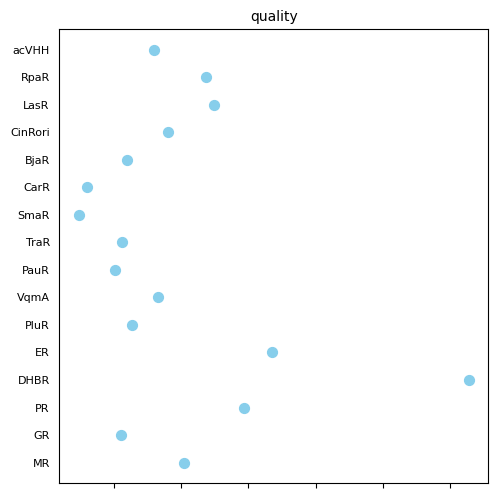

传感器 Fold Change 计算结果:
acVHH: 1.56e+02
RpaR: 5.34e+03
LasR: 9.36e+03
CinRori: 4.07e+02
BjaR: 2.47e+01
CarR: 1.56e+00
SmaR: 9.21e-01
TraR: 1.81e+01
PauR: 1.07e+01
VqmA: 2.09e+02
PluR: 3.47e+01
ER: 4.95e+05
DHBR: 3.51e+11
PR: 7.47e+04
GR: 1.60e+01
MR: 1.23e+03


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 定义常数
kd = 20.37469959

I0=0.04531675

Imax= 35.84931505    # 需要根据实际情况设置

# === k1 参数（来自表格） ===
sensor_k1 = {
    "acVHH": 0.01047924,
    "RpaR": 0.000268715,
    "LasR": 0.000171923,
    "CinRori": 0.003906623,
    "BjaR": 0.000153468,   
    "CarR": 0.024643659,   
    "SmaR": 0.007799755,   
    "TraR": 0.000109651,
    "PauR": 0.00012233,
    "VqmA": 0.007756991,
    "PluR": 0.000105019,
    "ER": 0.000002016960627,
    "DHBR": 4.21691E-22,
    "PR": 1.22917E-05,
    "GR": 0.000003901059096,
    "MR": 0.000003043266786
}

# === k2 参数（来自表格） ===
sensor_k2 = {
    "acVHH": 58.84004211,
    "RpaR": 0.007083518,
    "LasR": 0.256016091,
    "CinRori": 56.83673859,
    "BjaR": 0.002735345,
    "CarR": 8.49165E-06,
    "SmaR": 0.218537966,
    "TraR": 0.181526351,
    "PauR": 1.751281238,
    "VqmA": 32.64533058,
    "PluR": 0.455405602,
    "ER": 15.591256628348091,
    "DHBR": 0.039590602,
    "PR": 0.462590457,
    "GR": 0.035170104659471,
    "MR": 2.00561142
}

# === k3 参数（来自表格） ===
sensor_k3 = {
    "acVHH": 0.746886849,
    "RpaR": 0.760771692,
    "LasR": 225.0817618,
    "CinRori": 0.162220061,
    "BjaR": 0.050865889,
    "CarR": 538352547.7,
    "SmaR": 0.042606588,
    "TraR": 0.060416246,
    "PauR": 0.000427387,
    "VqmA": 0.020473023,
    "PluR": 0.000175967,
    "ER": 1.700406357783870,
    "DHBR": 13.17104327,
    "PR": 0.074821866,
    "GR": 0.000020954379849,
    "MR": 0.001243206
}

# === I 参数（来自表格） ===
sensor_I = {
    "acVHH": 1,
    "RpaR": 1000,
    "LasR": 10,
    "CinRori": 1,
    "BjaR": 100,
    "SmaR": 1,
    "TraR": 1,
    "CarR": 1,
    "PauR": 1,
    "PluR": 10,
    "VqmA": 10,
    "ER": 10,
    "DHBR": 1,
    "PR": 10,
    "GR": 100,
    "MR": 1,
}

# === kx1 参数（来自表格） ===
nuclear_kx1 = {
    "ER": 0.798527188158513,
    "DHBR": 0.001007507,
    "PR": 0.00273789,
    "GR": 1.776378776493321,
    "MR": 1.937182665
}

# === kx2 参数（来自表格） ===
nuclear_kx2 = {
    "ER": 0.191861964654868,
    "DHBR": 0.001604871,
    "PR": 0.921262549,
    "GR": 0.001928521,
    "MR": 1.619613647
}

# 定义 L 的范围
L_values = np.linspace(0.1, 10, 1000)

# 计算 P 值的通用函数
def calculate_P(L, x):
    fraction = (x - 1) / (x + 1)
    denominator = 1 + (L / 2) * fraction * kd
    # 避免除以零
    if np.any(denominator == 0):
        denominator = np.where(denominator == 0, 1e-10, denominator)
    return Imax * ((L / 2) * fraction * kd / denominator) 

# 计算非核受体的 P1（有诱导剂）
def calculate_non_nuclear_P1(L, k2, k3, I):
    x1 = np.sqrt(1 + 8 * L * (k2**2 * k3 * I**2))
    return calculate_P(L, x1)

# 计算非核受体的 P2（无诱导剂）
def calculate_non_nuclear_P2(L, k1):
    x2 = np.sqrt(1 + 8 * L * k1)
    return calculate_P(L, x2)

# 计算核受体的 P1（有诱导剂）
def calculate_nuclear_P1(L, k2, k3, I, kx2):
    x1 = np.sqrt(1 + 8 * L * (k2**2 * k3 * I**2 + k2**2 * k3 * kx2**2 * I**2))
    return calculate_P(L, x1)

# 计算核受体的 P2（无诱导剂）
def calculate_nuclear_P2(L, k1, kx1):
    x2 = np.sqrt(1 + 8 * L * (k1 + k1 * kx1**2))
    return calculate_P(L, x2)

# 存储数据
labels, fold_changes = [], []

# 遍历所有传感器，计算 fold change
for name in sensor_k1.keys():
    if name in sensor_k2 and name in sensor_k3 and name in sensor_I:
        k1 = sensor_k1[name]
        k2 = sensor_k2[name]
        k3 = sensor_k3[name]
        I_val = sensor_I[name]
        
        # 计算有诱导剂和无诱导剂时的 P 值
        if name in nuclear_kx1 and name in nuclear_kx2:
            # 核受体
            kx1 = nuclear_kx1[name]
            kx2 = nuclear_kx2[name]
            P1_with_I = calculate_nuclear_P1(L_values, k2, k3, I_val, kx2)
            P2_without_I = calculate_nuclear_P2(L_values, k1, kx1)
        else:
            # 非核受体
            P1_with_I = calculate_non_nuclear_P1(L_values, k2, k3, I_val)
            P2_without_I = calculate_non_nuclear_P2(L_values, k1)
        
        # 避免除以零
        P2_without_I = np.where(P2_without_I == 0, 1e-10, P2_without_I)
        
        # 计算 fold change (最大值)
        fold_change = np.max(P1_with_I / P2_without_I)
        
        # 检查是否为无穷大
        if np.isinf(fold_change):
            print(f"警告: {name} 的 fold change 为无穷大")
            # 使用一个很大的有限值代替无穷大
            fold_change = 1e20
        
        labels.append(name)
        fold_changes.append(fold_change)
    else:
        print(f"警告: 传感器 {name} 缺少必要的参数")

# 打印 DHBR 的详细计算信息
if "DHBR" in sensor_k1:
    k1 = sensor_k1["DHBR"]
    k2 = sensor_k2["DHBR"]
    k3 = sensor_k3["DHBR"]
    I_val = sensor_I["DHBR"]
    kx1 = nuclear_kx1["DHBR"]
    kx2 = nuclear_kx2["DHBR"]
    
    print("\nDHBR 详细计算:")
    print(f"k1 = {k1:.2e}")
    print(f"k2 = {k2:.2e}")
    print(f"k3 = {k3:.2e}")
    print(f"I = {I_val}")
    print(f"kx1 = {kx1:.2e}")
    print(f"kx2 = {kx2:.2e}")
    
    # 计算无诱导剂时的 P2
    x2 = np.sqrt(1 + 8 * L_values * (k1 + k1 * kx1**2))
    P2_without_I = calculate_P(L_values, x2)
    print(f"最小 P2 = {np.min(P2_without_I):.2e}")
    
    # 计算有诱导剂时的 P1
    x1 = np.sqrt(1 + 8 * L_values * (k2**2 * k3 * I_val**2 + k2**2 * k3 * kx2**2 * I_val**2))
    P1_with_I = calculate_P(L_values, x1)
    print(f"最大 P1 = {np.max(P1_with_I):.2e}")
    
    # 计算比值
    ratio = P1_with_I / P2_without_I
    print(f"最大比值 = {np.max(ratio):.2e}")

# 绘制图表 - 只显示点
fig, ax = plt.subplots(figsize=(5.08, 5.08))
y_pos = np.arange(len(labels))

# 使用散点图代替条形图，只显示点
ax.scatter(fold_changes, y_pos, color='skyblue', s=50)  # s参数控制点的大小

# 设置图表标签和标题
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title('quality', fontsize=10)
ax.invert_yaxis()  # 反转 y 轴，使得标签从上到下显示

# 设置x轴为对数尺度，因为比值范围很大
ax.set_xscale('log')

# 隐藏x轴的刻度值和标签
ax.set_xticklabels([])
ax.set_xlabel('')  # 清空x轴标签

# 隐藏y轴的刻度值（只保留标签）
ax.set_yticklabels(labels, fontsize=8)  # 保留y轴标签
ax.tick_params(axis='y', which='both', left=False)  # 隐藏y轴刻度线

# 自动调整布局
plt.tight_layout()

# 保存图表为 SVG 格式
plt.savefig("E:/Desktop/fold_change_comparison.svg", format='svg', transparent=True)

# 显示图表
plt.show()

# 打印所有计算结果
print("传感器 Fold Change 计算结果:")
for i, name in enumerate(labels):
    print(f"{name}: {fold_changes[i]:.2e}")


DHBR 详细计算:
k1 = 4.22e-22
k2 = 3.96e-02
k3 = 1.32e+01
I = 1
kx1 = 1.01e-03
kx2 = 1.60e-03
最小 P2 = 1.70e+00
最大 P1 = 1.69e+00
最大比值 = 9.92e-01


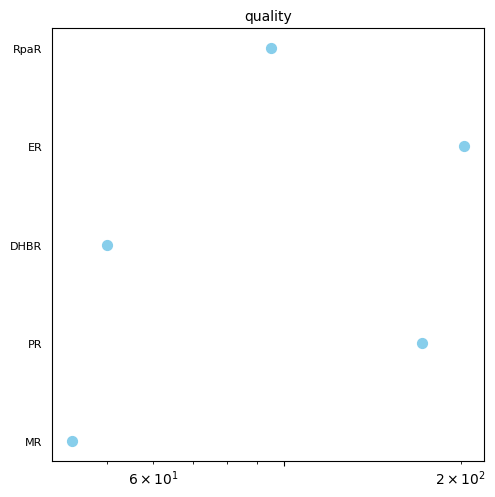

传感器 Fold Change 计算结果:
RpaR: 9.51e+01
ER: 2.03e+02
DHBR: 5.00e+01
PR: 1.72e+02
MR: 4.36e+01


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 定义常数
kd = 40.97704697

I0=0.1


Imax= 1.7    # 需要根据实际情况设置

# === k1 参数（来自表格） ===
sensor_k1 = {
    "RpaR": 0.000268715,
    "ER": 0.000002016960627,
    "DHBR": 4.21691E-22,
    "PR": 1.22917E-05,
    "MR": 0.000003043266786
}

# === k2 参数（来自表格） ===
sensor_k2 = {
    "RpaR": 0.007083518,
    "ER": 15.591256628348091,
    "DHBR": 0.039590602,
    "PR": 0.462590457,
    "MR": 2.00561142
}

# === k3 参数（来自表格） ===
sensor_k3 = {
    "RpaR": 0.760771692,
    "ER": 1.700406357783870,
    "DHBR": 13.17104327,
    "PR": 0.074821866,
    "MR": 0.001243206
}

# === I 参数（来自表格） ===
sensor_I = {
    "RpaR": 1000,
    "ER": 10,
    "DHBR": 1,
    "PR": 10,
    "MR": 1,
}

# === kx1 参数（来自表格） ===
nuclear_kx1 = {
    "ER": 0.798527188158513,
    "DHBR": 0.001007507,
    "PR": 0.00273789,
    "MR": 1.937182665
}

# === kx2 参数（来自表格） ===
nuclear_kx2 = {
    "ER": 0.191861964654868,
    "DHBR": 0.001604871,
    "PR": 0.921262549,
    "MR": 1.619613647
}

# 定义 L 的范围
L_values = np.linspace(0.1, 10, 1000)

# 计算 P 值的通用函数
def calculate_P(L, x):
    fraction = (x - 1) / (x + 1)
    denominator = 1 + (L / 2) * fraction * kd
    # 避免除以零
    if np.any(denominator == 0):
        denominator = np.where(denominator == 0, 1e-10, denominator)
    return Imax * (1/ denominator) 

# 计算非核受体的 P1（有诱导剂）
def calculate_non_nuclear_P1(L, k2, k3, I):
    x1 = np.sqrt(1 + 8 * L * (k2**2 * k3 * I**2))
    return calculate_P(L, x1)

# 计算非核受体的 P2（无诱导剂）
def calculate_non_nuclear_P2(L, k1):
    x2 = np.sqrt(1 + 8 * L * k1)
    return calculate_P(L, x2)

# 计算核受体的 P1（有诱导剂）
def calculate_nuclear_P1(L, k2, k3, I, kx2):
    x1 = np.sqrt(1 + 8 * L * (k2**2 * k3 * I**2 + k2**2 * k3 * kx2**2 * I**2))
    return calculate_P(L, x1)

# 计算核受体的 P2（无诱导剂）
def calculate_nuclear_P2(L, k1, kx1):
    x2 = np.sqrt(1 + 8 * L * (k1 + k1 * kx1**2))
    return calculate_P(L, x2)

# 存储数据
labels, fold_changes = [], []

# 遍历所有传感器，计算 fold change
for name in sensor_k1.keys():
    if name in sensor_k2 and name in sensor_k3 and name in sensor_I:
        k1 = sensor_k1[name]
        k2 = sensor_k2[name]
        k3 = sensor_k3[name]
        I_val = sensor_I[name]
        
        # 计算有诱导剂和无诱导剂时的 P 值
        if name in nuclear_kx1 and name in nuclear_kx2:
            # 核受体
            kx1 = nuclear_kx1[name]
            kx2 = nuclear_kx2[name]
            P1_with_I = calculate_nuclear_P1(L_values, k2, k3, I_val, kx2)
            P2_without_I = calculate_nuclear_P2(L_values, k1, kx1)
        else:
            # 非核受体
            P1_with_I = calculate_non_nuclear_P1(L_values, k2, k3, I_val)
            P2_without_I = calculate_non_nuclear_P2(L_values, k1)
        
        # 避免除以零
        P2_without_I = np.where(P2_without_I == 0, 1e-10, P2_without_I)
        
        # 计算 fold change (最大值)
        fold_change = np.max(P2_without_I / P1_with_I)
        
        # 检查是否为无穷大
        if np.isinf(fold_change):
            print(f"警告: {name} 的 fold change 为无穷大")
            # 使用一个很大的有限值代替无穷大
            fold_change = 1e20
        
        labels.append(name)
        fold_changes.append(fold_change)
    else:
        print(f"警告: 传感器 {name} 缺少必要的参数")

# 打印 DHBR 的详细计算信息
if "DHBR" in sensor_k1:
    k1 = sensor_k1["DHBR"]
    k2 = sensor_k2["DHBR"]
    k3 = sensor_k3["DHBR"]
    I_val = sensor_I["DHBR"]
    kx1 = nuclear_kx1["DHBR"]
    kx2 = nuclear_kx2["DHBR"]
    
    print("\nDHBR 详细计算:")
    print(f"k1 = {k1:.2e}")
    print(f"k2 = {k2:.2e}")
    print(f"k3 = {k3:.2e}")
    print(f"I = {I_val}")
    print(f"kx1 = {kx1:.2e}")
    print(f"kx2 = {kx2:.2e}")
    
    # 计算无诱导剂时的 P2
    x2 = np.sqrt(1 + 8 * L_values * (k1 + k1 * kx1**2))
    P2_without_I = calculate_P(L_values, x2)
    print(f"最小 P2 = {np.min(P2_without_I):.2e}")
    
    # 计算有诱导剂时的 P1
    x1 = np.sqrt(1 + 8 * L_values * (k2**2 * k3 * I_val**2 + k2**2 * k3 * kx2**2 * I_val**2))
    P1_with_I = calculate_P(L_values, x1)
    print(f"最大 P1 = {np.max(P1_with_I):.2e}")
    
    # 计算比值
    ratio = P1_with_I / P2_without_I
    print(f"最大比值 = {np.max(ratio):.2e}")

# 绘制图表 - 只显示点
fig, ax = plt.subplots(figsize=(5.08, 5.08))
y_pos = np.arange(len(labels))

# 使用散点图代替条形图，只显示点
ax.scatter(fold_changes, y_pos, color='skyblue', s=50)  # s参数控制点的大小

# 设置图表标签和标题
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title('quality', fontsize=10)
ax.invert_yaxis()  # 反转 y 轴，使得标签从上到下显示

# 设置x轴为对数尺度，因为比值范围很大
ax.set_xscale('log')

# 隐藏x轴的刻度值和标签
ax.set_xticklabels([])
ax.set_xlabel('')  # 清空x轴标签

# 隐藏y轴的刻度值（只保留标签）
ax.set_yticklabels(labels, fontsize=8)  # 保留y轴标签
ax.tick_params(axis='y', which='both', left=False)  # 隐藏y轴刻度线

# 自动调整布局
plt.tight_layout()

# 保存图表为 SVG 格式
#plt.savefig("E:/Desktop/fold_change_comparison.svg", format='svg', transparent=True)

# 显示图表
plt.show()

# 打印所有计算结果
print("传感器 Fold Change 计算结果:")
for i, name in enumerate(labels):
    print(f"{name}: {fold_changes[i]:.2e}")

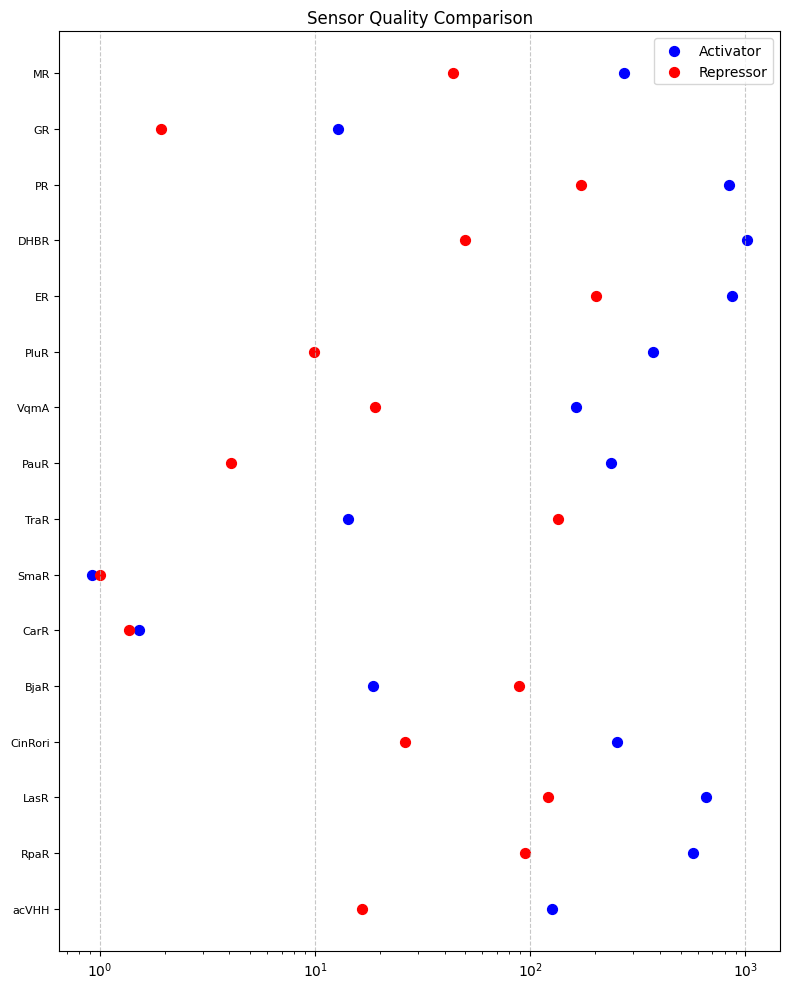

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 定义常数
kd = 40.97704697
Imax_repressor=1.7
Imax_activator=35.84931505
I0_repressor=0.1
I0_activator=0.035
# === 参数定义 ===
# k1 参数
sensor_k1 = {
    "acVHH": 0.01047924,
    "RpaR": 0.000268715,
    "LasR": 0.000171923,
    "CinRori": 0.003906623,
    "BjaR": 0.000153468,   
    "CarR": 0.024643659,   
    "SmaR": 0.007799755,   
    "TraR": 0.000109651,
    "PauR": 0.00012233,
    "VqmA": 0.007756991,
    "PluR": 0.000105019,
    "ER": 0.000002016960627,
    "DHBR": 4.21691E-22,
    "PR": 1.22917E-05,
    "GR": 0.000003901059096,
    "MR": 0.000003043266786
}

# k2 参数
sensor_k2 = {
    "acVHH": 58.84004211,
    "RpaR": 0.007083518,
    "LasR": 0.256016091,
    "CinRori": 56.83673859,
    "BjaR": 0.002735345,
    "CarR": 8.49165E-06,
    "SmaR": 0.218537966,
    "TraR": 0.181526351,
    "PauR": 1.751281238,
    "VqmA": 32.64533058,
    "PluR": 0.455405602,
    "ER": 15.591256628348091,
    "DHBR": 0.039590602,
    "PR": 0.462590457,
    "GR": 0.035170104659471,
    "MR": 2.00561142
}

# k3 参数
sensor_k3 = {
    "acVHH": 0.746886849,
    "RpaR": 0.760771692,
    "LasR": 225.0817618,
    "CinRori": 0.162220061,
    "BjaR": 0.050865889,
    "CarR": 538352547.7,
    "SmaR": 0.042606588,
    "TraR": 0.060416246,
    "PauR": 0.000427387,
    "VqmA": 0.020473023,
    "PluR": 0.000175967,
    "ER": 1.700406357783870,
    "DHBR": 13.17104327,
    "PR": 0.074821866,
    "GR": 0.000020954379849,
    "MR": 0.001243206
}

# I 参数 (activator)
sensor_I_activator = {
    "acVHH": 1,
    "RpaR": 1000,
    "LasR": 10,
    "CinRori": 1,
    "BjaR": 100,
    "SmaR": 1,
    "TraR": 1,
    "CarR": 1,
    "PauR": 10,
    "PluR": 100,
    "VqmA": 100,
    "ER": 0.1,
    "DHBR": 1000,
    "PR": 100,
    "GR": 100,
    "MR": 1,
}

# I 参数 (repressor)
sensor_I_repressor = {
    "acVHH": 1,
    "RpaR": 1000,
    "LasR": 10,
    "CinRori": 1,
    "BjaR": 1000,
    "SmaR": 1,
    "TraR": 100,
    "CarR": 1,
    "PauR": 1,
    "PluR": 10,
    "VqmA": 10,
    "ER": 10,
    "DHBR": 1,
    "PR": 10,
    "GR": 100,
    "MR": 1,
}

# kx1 参数
nuclear_kx1 = {
    "ER": 0.798527188158513,
    "DHBR": 0.001007507,
    "PR": 0.00273789,
    "GR": 1.776378776493321,
    "MR": 1.937182665
}

# kx2 参数
nuclear_kx2 = {
    "ER": 0.191861964654868,
    "DHBR": 0.001604871,
    "PR": 0.921262549,
    "GR": 0.001928521,
    "MR": 1.619613647
}

# 定义 L 的范围
L_values = np.linspace(0.1, 10, 1000)

# 计算 activator 的 P 值函数
def calculate_activator_P(L, x):
    fraction = (x - 1) / (x + 1)
    denominator = 1 + (L / 2) * fraction * kd
    if np.any(denominator == 0):
        denominator = np.where(denominator == 0, 1e-10, denominator)
    return Imax_activator * ((L / 2) * fraction * kd / denominator) + I0_activator

# 计算 repressor 的 P 值函数
def calculate_repressor_P(L, x):
    fraction = (x - 1) / (x + 1)
    denominator = 1 + (L / 2) * fraction * kd
    if np.any(denominator == 0):
        denominator = np.where(denominator == 0, 1e-10, denominator)
    return Imax_repressor * (1 / denominator)

# 计算 activator 的非核受体 P1（有诱导剂）
def calculate_activator_non_nuclear_P1(L, k2, k3, I):
    x1 = np.sqrt(1 + 8 * L * (k2**2 * k3 * I**2))
    return calculate_activator_P(L, x1)

# 计算 activator 的非核受体 P2（无诱导剂）
def calculate_activator_non_nuclear_P2(L, k1):
    x2 = np.sqrt(1 + 8 * L * k1)
    return calculate_activator_P(L, x2)

# 计算 activator 的核受体 P1（有诱导剂）
def calculate_activator_nuclear_P1(L, k2, k3, I, kx2):
    x1 = np.sqrt(1 + 8 * L * (k2**2 * k3 * I**2 + k2**2 * k3 * kx2**2 * I**2))
    return calculate_activator_P(L, x1)

# 计算 activator 的核受体 P2（无诱导剂）
def calculate_activator_nuclear_P2(L, k1, kx1):
    x2 = np.sqrt(1 + 8 * L * (k1 + k1 * kx1**2))
    return calculate_activator_P(L, x2)

# 计算 repressor 的非核受体 P1（有诱导剂）
def calculate_repressor_non_nuclear_P1(L, k2, k3, I):
    x1 = np.sqrt(1 + 8 * L * (k2**2 * k3 * I**2))
    return calculate_repressor_P(L, x1)

# 计算 repressor 的非核受体 P2（无诱导剂）
def calculate_repressor_non_nuclear_P2(L, k1):
    x2 = np.sqrt(1 + 8 * L * k1)
    return calculate_repressor_P(L, x2)

# 计算 repressor 的核受体 P1（有诱导剂）
def calculate_repressor_nuclear_P1(L, k2, k3, I, kx2):
    x1 = np.sqrt(1 + 8 * L * (k2**2 * k3 * I**2 + k2**2 * k3 * kx2**2 * I**2))
    return calculate_repressor_P(L, x1)

# 计算 repressor 的核受体 P2（无诱导剂）
def calculate_repressor_nuclear_P2(L, k1, kx1):
    x2 = np.sqrt(1 + 8 * L * (k1 + k1 * kx1**2))
    return calculate_repressor_P(L, x2)

# 计算 activator 的 fold change
def calculate_activator_fold_change():
    Imax_activator = 1.0
    I0_activator = 0.0
    
    labels, fold_changes = [], []
    
    for name in sensor_k1.keys():
        if name in sensor_k2 and name in sensor_k3 and name in sensor_I_activator:
            k1 = sensor_k1[name]
            k2 = sensor_k2[name]
            k3 = sensor_k3[name]
            I_val = sensor_I_activator[name]
            
            # 计算有诱导剂和无诱导剂时的 P 值
            if name in nuclear_kx1 and name in nuclear_kx2:
                # 核受体
                kx1 = nuclear_kx1[name]
                kx2 = nuclear_kx2[name]
                P1_with_I = calculate_activator_nuclear_P1(L_values, k2, k3, I_val, kx2)
                P2_without_I = calculate_activator_nuclear_P2(L_values, k1, kx1)
            else:
                # 非核受体
                P1_with_I = calculate_activator_non_nuclear_P1(L_values, k2, k3, I_val)
                P2_without_I = calculate_activator_non_nuclear_P2(L_values, k1)
            
            # 避免除以零
            P2_without_I = np.where(P2_without_I == 0, 1e-10, P2_without_I)
            
            # 计算 fold change (最大值)
            fold_change = np.max(P1_with_I / P2_without_I)
            
            # 检查是否为无穷大
            if np.isinf(fold_change):
                fold_change = 1e20
            
            labels.append(name)
            fold_changes.append(fold_change)
    
    return labels, fold_changes

# 计算 repressor 的 fold change
def calculate_repressor_fold_change():
    Imax_repressor = 1.7
    I0_repressor = 0.1
    
    labels, fold_changes = [], []
    
    for name in sensor_k1.keys():
        if name in sensor_k2 and name in sensor_k3 and name in sensor_I_repressor:
            k1 = sensor_k1[name]
            k2 = sensor_k2[name]
            k3 = sensor_k3[name]
            I_val = sensor_I_repressor[name]
            
            # 计算有诱导剂和无诱导剂时的 P 值
            if name in nuclear_kx1 and name in nuclear_kx2:
                # 核受体
                kx1 = nuclear_kx1[name]
                kx2 = nuclear_kx2[name]
                P1_with_I = calculate_repressor_nuclear_P1(L_values, k2, k3, I_val, kx2)
                P2_without_I = calculate_repressor_nuclear_P2(L_values, k1, kx1)
            else:
                # 非核受体
                P1_with_I = calculate_repressor_non_nuclear_P1(L_values, k2, k3, I_val)
                P2_without_I = calculate_repressor_non_nuclear_P2(L_values, k1)
            
            # 避免除以零
            P1_with_I = np.where(P1_with_I == 0, 1e-10, P1_with_I)
            
            # 计算 fold change (最大值)
            fold_change = np.max(P2_without_I / P1_with_I)
            
            # 检查是否为无穷大
            if np.isinf(fold_change):
                fold_change = 1e20
            
            labels.append(name)
            fold_changes.append(fold_change)
    
    return labels, fold_changes

# 计算 activator 和 repressor 的 fold change
activator_labels, activator_fold_changes = calculate_activator_fold_change()
repressor_labels, repressor_fold_changes = calculate_repressor_fold_change()

# 创建合并的图表
fig, ax = plt.subplots(figsize=(8, 10))

# y 轴位置，保证两类标签对齐
activator_y_pos = np.arange(len(activator_labels))
repressor_y_pos = activator_y_pos  # 不再偏移，直接对齐

# 绘制 activator 的点
ax.scatter(activator_fold_changes, activator_y_pos, color='blue', s=50, label='Activator')

# 绘制 repressor 的点（和 activator 重叠对齐）
ax.scatter(repressor_fold_changes, repressor_y_pos, color='red', s=50, label='Repressor')

# 设置图表标签和标题
ax.set_yticks(activator_y_pos)
ax.set_yticklabels(activator_labels, fontsize=8)
ax.set_title('Sensor Quality Comparison', fontsize=12)

# 设置x轴为对数尺度
ax.set_xscale('log')

# 添加图例
ax.legend(loc='best')

# 添加网格线
ax.grid(True, axis='x', linestyle='--', alpha=0.7)

# 自动调整布局
plt.tight_layout()

# 保存图表为 SVG 格式
plt.savefig("E:/Desktop/sensor_quality_comparison.svg", format='svg', transparent=True)

# 显示图表
plt.show()


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ================= DBD 参数 =================
dbds = [
    "CI434", "LexAs5", "LexAs17", "LexA87", "LexAs23", "HKCI",
    "RecApact", "DeoR", "PurR", "LexAs15", "LexAs14",
    "CI_OL1", "CI_OR1", "CI_Osym"
]
kds = [
    6.216347694, 40.97704697, 8.374494076, 0.745553315, 1.445352554,
    5.066512585, 1.03869567, 0.607055765, 1.13083303, 0.343528478,
    0.102414004, 30.08697891, 10.36936283, 10.53282547
]
I0s = [
    0.01, 0.035485714, 0.01, 0.015930056, 0.011797972, 0.008956896,
    0.016945722, 0.024571917, 0.006969286, 0.04531675,
    0.111188222, 0.13576227, 0.135905549, 0.272291827
]

# ================= 你的参数 (LBD相关) =================
Imax_repressor=1.7
Imax_activator=35.84931505

# k1 参数
sensor_k1 = {
    "acVHH": 0.01047924, "RpaR": 0.000268715, "LasR": 0.000171923, "CinRori": 0.003906623,
    "BjaR": 0.000153468, "CarR": 0.024643659, "SmaR": 0.007799755, "TraR": 0.000109651,
    "PauR": 0.00012233, "VqmA": 0.007756991, "PluR": 0.000105019,
    "ER": 0.000002016960627, "DHBR": 4.21691E-22, "PR": 1.22917E-05,
    "GR": 0.000003901059096, "MR": 0.000003043266786
}
# k2 参数
sensor_k2 = {
    "acVHH": 58.84004211, "RpaR": 0.007083518, "LasR": 0.256016091, "CinRori": 56.83673859,
    "BjaR": 0.002735345, "CarR": 8.49165E-06, "SmaR": 0.218537966, "TraR": 0.181526351,
    "PauR": 1.751281238, "VqmA": 32.64533058, "PluR": 0.455405602,
    "ER": 15.591256628348091, "DHBR": 0.039590602, "PR": 0.462590457,
    "GR": 0.035170104659471, "MR": 2.00561142
}
# k3 参数
sensor_k3 = {
    "acVHH": 0.746886849, "RpaR": 0.760771692, "LasR": 225.0817618, "CinRori": 0.162220061,
    "BjaR": 0.050865889, "CarR": 538352547.7, "SmaR": 0.042606588, "TraR": 0.060416246,
    "PauR": 0.000427387, "VqmA": 0.020473023, "PluR": 0.000175967,
    "ER": 1.700406357783870, "DHBR": 13.17104327, "PR": 0.074821866,
    "GR": 0.000020954379849, "MR": 0.001243206
}
# I 参数 (activator)
sensor_I_activator = {
    "acVHH": 1, "RpaR": 1000, "LasR": 10, "CinRori": 1, "BjaR": 1000, "SmaR": 1,
    "TraR": 100, "CarR": 1, "PauR": 10, "PluR": 100, "VqmA": 100,
    "ER": 0.1, "DHBR": 1000, "PR": 100, "GR": 100, "MR": 1
}
# I 参数 (repressor)
sensor_I_repressor = {
    "acVHH": 1, "RpaR": 1000, "LasR": 10, "CinRori": 1, "BjaR": 100, "SmaR": 1,
    "TraR": 1, "CarR": 1, "PauR": 1, "PluR": 10, "VqmA": 10,
    "ER": 10, "DHBR": 1, "PR": 10, "GR": 100, "MR": 1
}
# kx1 参数
nuclear_kx1 = {"ER": 0.798527188158513, "DHBR": 0.001007507, "PR": 0.00273789,
               "GR": 1.776378776493321, "MR": 1.937182665}
# kx2 参数
nuclear_kx2 = {"ER": 0.191861964654868, "DHBR": 0.001604871, "PR": 0.921262549,
               "GR": 0.001928521, "MR": 1.619613647}

# ================= 模型函数 =================
L_values = np.linspace(0.1, 10, 1000)

def calculate_activator_P(L, x, kd, I0):
    fraction = (x - 1) / (x + 1)
    denominator = 1 + (L / 2) * fraction * kd
    denominator = np.where(denominator == 0, 1e-10, denominator)
    return Imax_activator * ((L / 2) * fraction * kd / denominator) 

def calculate_repressor_P(L, x, kd, I0):
    fraction = (x - 1) / (x + 1)
    denominator = 1 + (L / 2) * fraction * kd
    denominator = np.where(denominator == 0, 1e-10, denominator)
    return Imax_repressor * (1 / denominator) 

# ================= 计算 FC 函数 =================
def compute_fold_changes(kd, I0):
    activator_labels, activator_fold_changes = [], []
    repressor_labels, repressor_fold_changes = [], []

    for name in sensor_k1.keys():
        if name in sensor_k2 and name in sensor_k3:
            k1, k2, k3 = sensor_k1[name], sensor_k2[name], sensor_k3[name]
            # Activator
            if name in sensor_I_activator:
                I_val = sensor_I_activator[name]
                if name in nuclear_kx1 and name in nuclear_kx2:
                    kx1, kx2 = nuclear_kx1[name], nuclear_kx2[name]
                    x1 = np.sqrt(1 + 8 * L_values * (k2**2 * k3 * I_val**2 + k2**2 * k3 * kx2**2 * I_val**2))
                    x2 = np.sqrt(1 + 8 * L_values * (k1 + k1 * kx1**2))
                else:
                    x1 = np.sqrt(1 + 8 * L_values * (k2**2 * k3 * I_val**2))
                    x2 = np.sqrt(1 + 8 * L_values * k1)

                P1 = calculate_activator_P(L_values, x1, kd, I0)
                P2 = calculate_activator_P(L_values, x2, kd, I0)
                fold_change = np.max(P1 / np.where(P2 == 0, 1e-10, P2))
                activator_labels.append(name)
                activator_fold_changes.append(fold_change)

            # Repressor
            if name in sensor_I_repressor:
                I_val = sensor_I_repressor[name]
                if name in nuclear_kx1 and name in nuclear_kx2:
                    kx1, kx2 = nuclear_kx1[name], nuclear_kx2[name]
                    x1 = np.sqrt(1 + 8 * L_values * (k2**2 * k3 * I_val**2 + k2**2 * k3 * kx2**2 * I_val**2))
                    x2 = np.sqrt(1 + 8 * L_values * (k1 + k1 * kx1**2))
                else:
                    x1 = np.sqrt(1 + 8 * L_values * (k2**2 * k3 * I_val**2))
                    x2 = np.sqrt(1 + 8 * L_values * k1)

                P1 = calculate_repressor_P(L_values, x1, kd, I0)
                P2 = calculate_repressor_P(L_values, x2, kd, I0)
                fold_change = np.max(np.where(P1 == 0, 1e-10, P2) / np.where(P1 == 0, 1e-10, P1))
                repressor_labels.append(name)
                repressor_fold_changes.append(fold_change)

    return activator_labels, activator_fold_changes, repressor_labels, repressor_fold_changes

# ================= 主循环 =================
all_results = []

for dbd, kd, I0 in zip(dbds, kds, I0s):
    act_labels, act_fc, rep_labels, rep_fc = compute_fold_changes(kd, I0)

    # 保存到结果表
    for l, fc in zip(act_labels, act_fc):
        all_results.append([dbd, l, "Activator", fc])
    for l, fc in zip(rep_labels, rep_fc):
        all_results.append([dbd, l, "Repressor", fc])

    # 绘图
    fig, ax = plt.subplots(figsize=(5.08, 5.08))
    y_pos = np.arange(len(act_labels))
    ax.scatter(act_fc, y_pos, color="blue", s=50, label="Activator")
    ax.scatter(rep_fc, y_pos, color="red", s=50, label="Repressor")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(act_labels, fontsize=8)
    ax.set_title(f"{dbd} - Sensor Quality", fontsize=12)
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True, axis="x", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"E:/Desktop/quality/{dbd}_sensor_quality.svg", format="svg", transparent=True)
    plt.close()

# ================= 输出 CSV =================
df = pd.DataFrame(all_results, columns=["DBD", "LBD", "Type", "FoldChange"])
df.to_csv("E:/Desktop/quality/sensor_quality_all.csv", index=False)


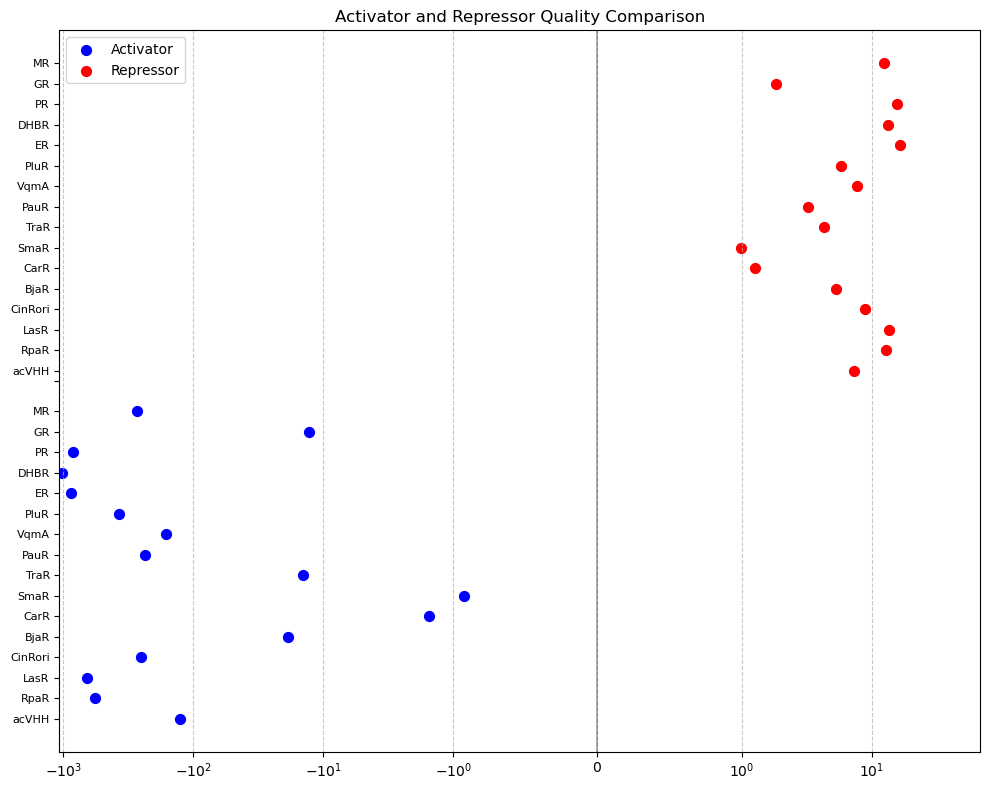

Activator Fold Change 计算结果:
acVHH: 1.27e+02
RpaR: 5.70e+02
LasR: 6.58e+02
CinRori: 2.53e+02
BjaR: 1.86e+01
CarR: 1.52e+00
SmaR: 9.21e-01
TraR: 1.42e+01
PauR: 2.37e+02
VqmA: 1.62e+02
PluR: 3.70e+02
ER: 8.69e+02
DHBR: 1.02e+03
PR: 8.39e+02
GR: 1.28e+01
MR: 2.72e+02

Repressor Fold Change 计算结果:
acVHH: 7.28e+00
RpaR: 1.28e+01
LasR: 1.35e+01
CinRori: 8.85e+00
BjaR: 5.29e+00
CarR: 1.26e+00
SmaR: 9.98e-01
TraR: 4.27e+00
PauR: 3.26e+00
VqmA: 7.76e+00
PluR: 5.85e+00
ER: 1.64e+01
DHBR: 1.34e+01
PR: 1.57e+01
GR: 1.82e+00
MR: 1.25e+01


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 定义常数
kd = 40.97704697
Imax_repressor=1.7
Imax_activator=35.84931505
I0_repressor=0.1
I0_activator=0.035
# === 参数定义 ===
# k1 参数
sensor_k1 = {
    "acVHH": 0.01047924,
    "RpaR": 0.000268715,
    "LasR": 0.000171923,
    "CinRori": 0.003906623,
    "BjaR": 0.000153468,   
    "CarR": 0.024643659,   
    "SmaR": 0.007799755,   
    "TraR": 0.000109651,
    "PauR": 0.00012233,
    "VqmA": 0.007756991,
    "PluR": 0.000105019,
    "ER": 0.000002016960627,
    "DHBR": 4.21691E-22,
    "PR": 1.22917E-05,
    "GR": 0.000003901059096,
    "MR": 0.000003043266786
}

# k2 参数
sensor_k2 = {
    "acVHH": 58.84004211,
    "RpaR": 0.007083518,
    "LasR": 0.256016091,
    "CinRori": 56.83673859,
    "BjaR": 0.002735345,
    "CarR": 8.49165E-06,
    "SmaR": 0.218537966,
    "TraR": 0.181526351,
    "PauR": 1.751281238,
    "VqmA": 32.64533058,
    "PluR": 0.455405602,
    "ER": 15.591256628348091,
    "DHBR": 0.039590602,
    "PR": 0.462590457,
    "GR": 0.035170104659471,
    "MR": 2.00561142
}

# k3 参数
sensor_k3 = {
    "acVHH": 0.746886849,
    "RpaR": 0.760771692,
    "LasR": 225.0817618,
    "CinRori": 0.162220061,
    "BjaR": 0.050865889,
    "CarR": 538352547.7,
    "SmaR": 0.042606588,
    "TraR": 0.060416246,
    "PauR": 0.000427387,
    "VqmA": 0.020473023,
    "PluR": 0.000175967,
    "ER": 1.700406357783870,
    "DHBR": 13.17104327,
    "PR": 0.074821866,
    "GR": 0.000020954379849,
    "MR": 0.001243206
}

# I 参数 (activator)
sensor_I_activator = {
    "acVHH": 1,
    "RpaR": 1000,
    "LasR": 10,
    "CinRori": 1,
    "BjaR": 100,
    "SmaR": 1,
    "TraR": 1,
    "CarR": 1,
    "PauR": 10,
    "PluR": 100,
    "VqmA": 100,
    "ER": 0.1,
    "DHBR": 1000,
    "PR": 100,
    "GR": 100,
    "MR": 1,
}

# I 参数 (repressor)
sensor_I_repressor = {
    "acVHH": 1,
    "RpaR": 1000,
    "LasR": 10,
    "CinRori": 1,
    "BjaR": 100,
    "SmaR": 1,
    "TraR": 1,
    "CarR": 1,
    "PauR": 1,
    "PluR": 10,
    "VqmA": 10,
    "ER": 10,
    "DHBR": 1,
    "PR": 10,
    "GR": 100,
    "MR": 1,
}

# kx1 参数
nuclear_kx1 = {
    "ER": 0.798527188158513,
    "DHBR": 0.001007507,
    "PR": 0.00273789,
    "GR": 1.776378776493321,
    "MR": 1.937182665
}

# kx2 参数
nuclear_kx2 = {
    "ER": 0.191861964654868,
    "DHBR": 0.001604871,
    "PR": 0.921262549,
    "GR": 0.001928521,
    "MR": 1.619613647
}

# 定义 L 的范围
L_values = np.linspace(0.1, 10, 1000)

# 计算 activator 的 P 值函数
def calculate_activator_P(L, x):
    fraction = (x - 1) / (x + 1)
    denominator = 1 + (L / 2) * fraction * kd
    if np.any(denominator == 0):
        denominator = np.where(denominator == 0, 1e-10, denominator)
    return Imax_activator * ((L / 2) * fraction * kd / denominator) + I0_activator

# 计算 repressor 的 P 值函数
def calculate_repressor_P(L, x):
    fraction = (x - 1) / (x + 1)
    denominator = 1 + (L / 2) * fraction * kd
    if np.any(denominator == 0):
        denominator = np.where(denominator == 0, 1e-10, denominator)
    return Imax_repressor * (1 / denominator) + I0_repressor

# 计算 activator 的非核受体 P1（有诱导剂）
def calculate_activator_non_nuclear_P1(L, k2, k3, I):
    x1 = np.sqrt(1 + 8 * L * (k2**2 * k3 * I**2))
    return calculate_activator_P(L, x1)

# 计算 activator 的非核受体 P2（无诱导剂）
def calculate_activator_non_nuclear_P2(L, k1):
    x2 = np.sqrt(1 + 8 * L * k1)
    return calculate_activator_P(L, x2)

# 计算 activator 的核受体 P1（有诱导剂）
def calculate_activator_nuclear_P1(L, k2, k3, I, kx2):
    x1 = np.sqrt(1 + 8 * L * (k2**2 * k3 * I**2 + k2**2 * k3 * kx2**2 * I**2))
    return calculate_activator_P(L, x1)

# 计算 activator 的核受体 P2（无诱导剂）
def calculate_activator_nuclear_P2(L, k1, kx1):
    x2 = np.sqrt(1 + 8 * L * (k1 + k1 * kx1**2))
    return calculate_activator_P(L, x2)

# 计算 repressor 的非核受体 P1（有诱导剂）
def calculate_repressor_non_nuclear_P1(L, k2, k3, I):
    x1 = np.sqrt(1 + 8 * L * (k2**2 * k3 * I**2))
    return calculate_repressor_P(L, x1)

# 计算 repressor 的非核受体 P2（无诱导剂）
def calculate_repressor_non_nuclear_P2(L, k1):
    x2 = np.sqrt(1 + 8 * L * k1)
    return calculate_repressor_P(L, x2)

# 计算 repressor 的核受体 P1（有诱导剂）
def calculate_repressor_nuclear_P1(L, k2, k3, I, kx2):
    x1 = np.sqrt(1 + 8 * L * (k2**2 * k3 * I**2 + k2**2 * k3 * kx2**2 * I**2))
    return calculate_repressor_P(L, x1)

# 计算 repressor 的核受体 P2（无诱导剂）
def calculate_repressor_nuclear_P2(L, k1, kx1):
    x2 = np.sqrt(1 + 8 * L * (k1 + k1 * kx1**2))
    return calculate_repressor_P(L, x2)

# 计算 activator 的 fold change
def calculate_activator_fold_change():
    Imax_activator = 1.0
    I0_activator = 0.0
    
    labels, fold_changes = [], []
    
    for name in sensor_k1.keys():
        if name in sensor_k2 and name in sensor_k3 and name in sensor_I_activator:
            k1 = sensor_k1[name]
            k2 = sensor_k2[name]
            k3 = sensor_k3[name]
            I_val = sensor_I_activator[name]
            
            # 计算有诱导剂和无诱导剂时的 P 值
            if name in nuclear_kx1 and name in nuclear_kx2:
                # 核受体
                kx1 = nuclear_kx1[name]
                kx2 = nuclear_kx2[name]
                P1_with_I = calculate_activator_nuclear_P1(L_values, k2, k3, I_val, kx2)
                P2_without_I = calculate_activator_nuclear_P2(L_values, k1, kx1)
            else:
                # 非核受体
                P1_with_I = calculate_activator_non_nuclear_P1(L_values, k2, k3, I_val)
                P2_without_I = calculate_activator_non_nuclear_P2(L_values, k1)
            
            # 避免除以零
            P2_without_I = np.where(P2_without_I == 0, 1e-10, P2_without_I)
            
            # 计算 fold change (最大值)
            fold_change = np.max(P1_with_I / P2_without_I)
            
            # 检查是否为无穷大
            if np.isinf(fold_change):
                fold_change = 1e20
            
            labels.append(name)
            fold_changes.append(fold_change)
    
    return labels, fold_changes

# 计算 repressor 的 fold change
def calculate_repressor_fold_change():
    Imax_repressor = 1.7
    I0_repressor = 0.1
    
    labels, fold_changes = [], []
    
    for name in sensor_k1.keys():
        if name in sensor_k2 and name in sensor_k3 and name in sensor_I_repressor:
            k1 = sensor_k1[name]
            k2 = sensor_k2[name]
            k3 = sensor_k3[name]
            I_val = sensor_I_repressor[name]
            
            # 计算有诱导剂和无诱导剂时的 P 值
            if name in nuclear_kx1 and name in nuclear_kx2:
                # 核受体
                kx1 = nuclear_kx1[name]
                kx2 = nuclear_kx2[name]
                P1_with_I = calculate_repressor_nuclear_P1(L_values, k2, k3, I_val, kx2)
                P2_without_I = calculate_repressor_nuclear_P2(L_values, k1, kx1)
            else:
                # 非核受体
                P1_with_I = calculate_repressor_non_nuclear_P1(L_values, k2, k3, I_val)
                P2_without_I = calculate_repressor_non_nuclear_P2(L_values, k1)
            
            # 避免除以零
            P1_with_I = np.where(P1_with_I == 0, 1e-10, P1_with_I)
            
            # 计算 fold change (最大值)
            fold_change = np.max(P2_without_I / P1_with_I)
            
            # 检查是否为无穷大
            if np.isinf(fold_change):
                fold_change = 1e20
            
            labels.append(name)
            fold_changes.append(fold_change)
    
    return labels, fold_changes

# 计算 activator 和 repressor 的 fold change
activator_labels, activator_fold_changes = calculate_activator_fold_change()
repressor_labels, repressor_fold_changes = calculate_repressor_fold_change()

# 创建合并的图表
fig, ax = plt.subplots(figsize=(10, 8))

# 绘制 activator 的点（左侧，负值）
activator_y_pos = np.arange(len(activator_labels))
activator_x_pos = [-x for x in activator_fold_changes]  # 负值，放在左侧
ax.scatter(activator_x_pos, activator_y_pos, color='blue', s=50, label='Activator')

# 绘制 repressor 的点（右侧，正值）
repressor_y_pos = np.arange(len(repressor_labels)) + len(activator_labels) + 1  # 偏移位置，避免重叠
ax.scatter(repressor_fold_changes, repressor_y_pos, color='red', s=50, label='Repressor')

# 设置图表标签和标题
all_labels = activator_labels + [""] + repressor_labels  # 添加空字符串作为分隔
all_y_pos = np.concatenate([activator_y_pos, [len(activator_labels) + 0.5], repressor_y_pos])  # 添加分隔位置

ax.set_yticks(all_y_pos)
ax.set_yticklabels(all_labels, fontsize=8)
ax.set_title('Activator and Repressor Quality Comparison', fontsize=12)

# 添加垂直中线
ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# 设置x轴为对数尺度，但需要处理负值
ax.set_xscale('symlog', linthresh=1.0)

# 添加图例
ax.legend(loc='best')

# 添加网格线
ax.grid(True, axis='x', linestyle='--', alpha=0.7)

# 自动调整布局
plt.tight_layout()

# 保存图表为 SVG 格式
plt.savefig("E:/Desktop/activator_repressor_comparison.svg", format='svg', transparent=True)

# 显示图表
plt.show()

# 打印所有计算结果
print("Activator Fold Change 计算结果:")
for i, name in enumerate(activator_labels):
    print(f"{name}: {activator_fold_changes[i]:.2e}")

print("\nRepressor Fold Change 计算结果:")
for i, name in enumerate(repressor_labels):
    print(f"{name}: {repressor_fold_changes[i]:.2e}")

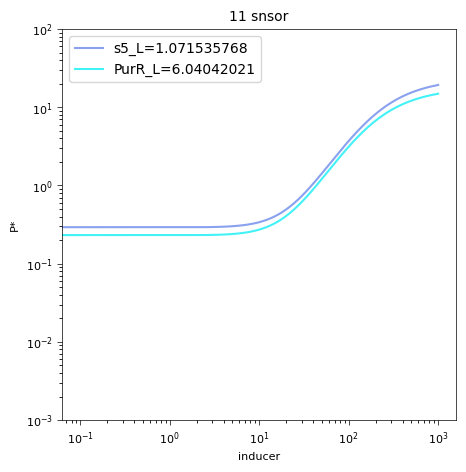

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd
from scipy.interpolate import interp1d

# 设置x和y的坐标范围
I= np.arange(0,1000,0.1)
#kd= np.arange(10,100000,1)
#I= np.arange(0,10,0.01)
#I1=1000
#I2=100
#I=0.000000001
#L= np.arange(0,10,0.001)
L=1.071535768



L1=6.04042021


kd1=40.97704697


kd2=1.13083303


k1=0.000153468

k2=0.002735345

k3=0.050865889


Imax =35.84931505


x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))

x2 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L1 * (k2*k2*k3*I*I+ k1 ))

F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434

F2=np.log(L1 / 2) + np.log((x2 - (k2*I+1)) / (x2 + (k2*I+1))) + np.log(kd2) #LexAs5
 
P1 = (Imax / (1 + np.exp(-F1)))+ 0.035485714

P2 = (Imax / (1 + np.exp(-F2))) +0.006969286


#y1=np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)*(-50*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 10*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8 + 1 - 1/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))) + (I - 10)*(80*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4)*sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (I - 10)**2*(4*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (8*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4 - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8)*np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)
fig, ax = plt.subplots(figsize=(5.08,5.08))
#ax.plot(L, P3,linewidth=1.5,label='master curve',c='black',linestyle='--')
ax.plot(I, P1,linewidth=1.5,label='s5_L=1.071535768',color='#89A1EF')
ax.plot(I, P2,linewidth=1.5,label='PurR_L=6.04042021',color='#42F2F7')


plt.legend(loc='upper left')
#plt.annotate('P1= {:.4f}'.format(P1), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')




#plt.annotate('P2= {:.4f}'.format(P2), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')
#ax.plot(L, P2, label="P2")
#ax.scatter(x, y)
def func(I,L, k1, k2, k3):  
            if not 0 < k1 or not 0 < k2 or not 0 < k3:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0)

# 设置横纵坐标轴的取值范围和标签
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("inducer",fontsize=8)
ax.set_ylabel("P*",fontsize=8)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5,labelsize=8)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'
ax.set_ylim((10**(-3)),10**2)

# 添加图例并显示图形
plt.title('11 snsor',fontsize=10)

plt.savefig("E:\Desktop\\12s\\11 snsor_curve.svg")
plt.show()

最大 L 差值: 3.5834518278898106
对应表达量 P: 0.7945869778829339
L1 = 3.669142378402494, L2 = 0.08569055051268347


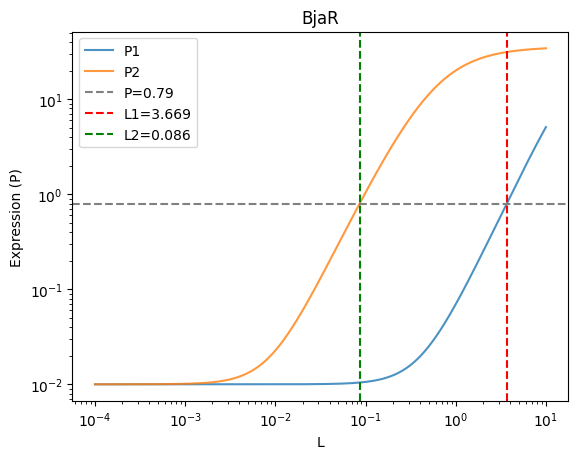

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 参数设置
I = 1000
k1 =0.000268715

k2= 0.007083518

k3 = 0.760771692

kd = 6.216347694

Imax = 35.84931505
I0 = 0.01


# L 值的范围（可以根据实际调整）
L_values = np.logspace(-4, 1, 1000)

# 计算 P1 和 P2 对应的表达量
def calc_P1(L):
    x1 = np.sqrt(1 + 8 * L * k1)
    F1 = np.log(L / 2) + np.log((x1 - 1) / (x1 + 1)) + np.log(kd)
    return (Imax / (1 + np.exp(-F1))) + I0

def calc_P2(L):
    x2 = np.sqrt((k2 * I + 1)**2 + 8 * L * (k2**2 * k3 * I**2 + k1))
    F2 = np.log(L / 2) + np.log((x2 - (k2 * I + 1)) / (x2 + (k2 * I + 1))) + np.log(kd)
    return (Imax / (1 + np.exp(-F2))) + I0

P1_values = calc_P1(L_values)
P2_values = calc_P2(L_values)

# 构建反函数 P -> L 的映射（注意这里允许多对一）
def get_L_for_P(P_curve, L_curve, P_target, tolerance=0.01):
    """在 P_curve 中找出接近 P_target 的所有 L 值"""
    mask = np.abs(P_curve - P_target) < tolerance
    return L_curve[mask]

# 扫描多个 P 水平线
P_scan = np.linspace(np.max([P1_values.min(), P2_values.min()]),
                     np.min([P1_values.max(), P2_values.max()]), 500)

max_diff = 0
best_P = None
best_L1 = None
best_L2 = None

for P_target in P_scan:
    Ls1 = get_L_for_P(P1_values, L_values, P_target, tolerance=0.001)
    Ls2 = get_L_for_P(P2_values, L_values, P_target, tolerance=0.001)
    for l1 in Ls1:
        for l2 in Ls2:
            diff = abs(l1 - l2)
            if diff > max_diff:
                max_diff = diff
                best_P = P_target
                best_L1 = l1
                best_L2 = l2

print(f"最大 L 差值: {max_diff}")
print(f"对应表达量 P: {best_P}")
print(f"L1 = {best_L1}, L2 = {best_L2}")

# 可视化
plt.plot(L_values, P1_values, label='P1', alpha=0.8)
plt.plot(L_values, P2_values, label='P2', alpha=0.8)
plt.axhline(best_P, color='gray', linestyle='--', label=f'P={best_P:.2f}')
plt.axvline(best_L1, color='red', linestyle='--', label=f'L1={best_L1:.3f}')
plt.axvline(best_L2, color='green', linestyle='--', label=f'L2={best_L2:.3f}')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("L")
plt.ylabel("Expression (P)")
plt.legend()
plt.title("BjaR")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 参数设置
I = 1000
k1 =0.000268715

k2= 0.007083518

k3 = 0.760771692


Imax = 35.84931505
I0 = 0.01


# L 值的范围（可以根据实际调整）
L_values = np.logspace(-4, 1, 1000)

# 计算 P1 和 P2 对应的表达量
def calc_P1(L):
    x1 = np.sqrt(1 + 8 * L * k1)
    F1 = np.log(L / 2) + np.log((x1 - 1) / (x1 + 1)) + np.log(kd)
    return (Imax / (1 + np.exp(-F1))) + I0

def calc_P2(L):
    x2 = np.sqrt((k2 * I + 1)**2 + 8 * L * (k2**2 * k3 * I**2 + k1))
    F2 = np.log(L / 2) + np.log((x2 - (k2 * I + 1)) / (x2 + (k2 * I + 1))) + np.log(kd)
    return (Imax / (1 + np.exp(-F2))) + I0

P1_values = calc_P1(L_values)
P2_values = calc_P2(L_values)

# 构建反函数 P -> L 的映射（注意这里允许多对一）
def get_L_for_P(P_curve, L_curve, P_target, tolerance=0.01):
    """在 P_curve 中找出接近 P_target 的所有 L 值"""
    mask = np.abs(P_curve - P_target) < tolerance
    return L_curve[mask]

# 扫描多个 P 水平线
P_scan = np.linspace(np.max([P1_values.min(), P2_values.min()]),
                     np.min([P1_values.max(), P2_values.max()]), 500)

max_diff = 0
best_P = None
best_L1 = None
best_L2 = None

for P_target in P_scan:
    Ls1 = get_L_for_P(P1_values, L_values, P_target, tolerance=0.001)
    Ls2 = get_L_for_P(P2_values, L_values, P_target, tolerance=0.001)
    for l1 in Ls1:
        for l2 in Ls2:
            diff = abs(l1 - l2)
            if diff > max_diff:
                max_diff = diff
                best_P = P_target
                best_L1 = l1
                best_L2 = l2

print(f"最大 L 差值: {max_diff}")
print(f"对应表达量 P: {best_P}")
print(f"L1 = {best_L1}, L2 = {best_L2}")

# 可视化
plt.plot(L_values, P1_values, label='P1', alpha=0.8)
plt.plot(L_values, P2_values, label='P2', alpha=0.8)
plt.axhline(best_P, color='gray', linestyle='--', label=f'P={best_P:.2f}')
plt.axvline(best_L1, color='red', linestyle='--', label=f'L1={best_L1:.3f}')
plt.axvline(best_L2, color='green', linestyle='--', label=f'L2={best_L2:.3f}')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("L")
plt.ylabel("Expression (P)")
plt.legend()
plt.title("BjaR")
plt.show()


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# 常数
I = 1000
k2 = 0.007083518
k3 = 0.760771692
Imax = 35.84931505
I0 = 0.035485714  # 所有DBD统一的I0值

# DBD 名称
names = [
    "CI434", "LexAs5", "LexAs17", "LexA87", "LexAs23", "HKCI", "RecApact",
    "DeoR", "PurR", "LexAs15", "LexAs14", "CI OL1", "CI OR1", "CI Osym",
    "DBP35", "DBP57"
]

# 对应 kd 和 k1
kd_list = [
    6.216347694, 40.97704697, 5.374494076, 0.745553315, 1.445352554, 5.066512585,
    1.03869567, 0.607055765, 1.13083303, 0.343528478, 0.102414004, 30.08697891,
    10.36936283, 10.53282547, 7.722134559, 0.12015283
]

k1_list = [
    0.001020641, 0.000244948, 0.000300262, 0.002035563, 0.000392227, 0.000776108,
    0.001141985, 0.00050128, 0.000475586, 0.000292669, 0.000403356, 0.000293138,
    0.000595765, 0.000476824, 0.00067405, 0.1990025
]

# L 值范围
L_values = np.logspace(-2, 1, 1000)

# 模型函数
def calc_P1(L, kd, k1):
    x1 = np.sqrt(1 + 8 * L * k1)
    F1 = np.log(L / 2) + np.log((x1 - 1) / (x1 + 1)) + np.log(kd)
    return (Imax / (1 + np.exp(-F1))) + I0

def calc_P2(L, kd, k1):
    x2 = np.sqrt((k2 * I + 1)**2 + 8 * L * (k2**2 * k3 * I**2 + k1))
    F2 = np.log(L / 2) + np.log((x2 - (k2 * I + 1)) / (x2 + (k2 * I + 1))) + np.log(kd)
    return (Imax / (1 + np.exp(-F2))) + I0

# 查找某个 P 对应的 L（P->L逆函数）
def get_L_for_P(P_curve, L_curve, P_target, tolerance=0.001):
    mask = np.abs(P_curve - P_target) < tolerance
    return L_curve[mask]

# 创建输出目录
output_dir = "E:/Desktop/DBDquality"
os.makedirs(output_dir, exist_ok=True)

results = []

# 批量处理
for name, kd, k1 in zip(names, kd_list, k1_list):
    P1_values = calc_P1(L_values, kd, k1)
    P2_values = calc_P2(L_values, kd, k1)

    P_scan = np.linspace(
        max(P1_values.min(), P2_values.min()),
        min(P1_values.max(), P2_values.max()),
        500
    )

    max_diff = 0
    best_P = None
    best_L1 = None
    best_L2 = None

    for P_target in P_scan:
        Ls1 = get_L_for_P(P1_values, L_values, P_target)
        Ls2 = get_L_for_P(P2_values, L_values, P_target)
        for l1 in Ls1:
            for l2 in Ls2:
                diff = abs(l1 - l2)
                if diff > max_diff:
                    max_diff = diff
                    best_P = P_target
                    best_L1 = l1
                    best_L2 = l2

    # 保存结果
    results.append({
        "Name": name,
        "kd": kd,
        "k1": k1,
        "I0": I0,
        "Max_L_Diff": max_diff,
        "Best_P": best_P,
        "L1": best_L1,
        "L2": best_L2
    })

    # 绘图保存
    plt.figure(figsize=(5.08, 5.08))
    plt.plot(L_values, P1_values, label='P1', alpha=0.8)
    plt.plot(L_values, P2_values, label='P2', alpha=0.8)
    if best_P:
        plt.axhline(best_P, color='gray', linestyle='--', label=f'P={best_P:.2f}')
        plt.axvline(best_L1, color='red', linestyle='--', label=f'L1={best_L1:.3f}')
        plt.axvline(best_L2, color='green', linestyle='--', label=f'L2={best_L2:.3f}')
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("L")
    plt.ylabel("Expression (P)")
    plt.title(name)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{name}.svg"))
    plt.close()

# 保存 CSV
df = pd.DataFrame(results)
df.to_csv(os.path.join(output_dir, "RpaR_allDBD.csv"), index=False)


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# 常数
I = 1000
k2 = 0.007083518
k3 = 0.760771692
Imax = 35.84931505

# 更新后的参数列表
names = [
    "CI434", "LexAs5", "LexAs17", "LexA87", "LexAs23", "HKCI", "RecApact",
    "DeoR", "PurR", "LexAs15", "LexAs14", "CI OL1", "CI OR1", "CI Osym",
    "DBP35", "DBP57"
]

kd_list = [
    6.216347694, 40.97704697, 5.374494076, 0.745553315, 1.445352554, 5.066512585,
    1.03869567, 0.607055765, 1.13083303, 0.343528478, 0.102414004, 30.08697891,
    10.36936283, 10.53282547, 0.59714266, 0.12015283
]

k1_list = [
    0.00091232,	0.000182163,	0.000272187,	0.002035562	,0.000220385	,
    0.000737614	,0.004023064	,0.000291329	,0.000292589,	0.000247827	,0.000186733	,
    0.000205093	,0.000394207,	0.000336667,	0.011752169	,0.165383636

]

# 使用原始 I0 值（如果你有新的 I0，可以替换）
I0_list = [
    0.01, 0.035485714, 0.01, 0.015930056, 0.011797972, 0.008956896,
    0.016945722, 0.024571917, 0.006969286, 0.04531675, 0.111188222,
    0.13576227, 0.135905549, 0.272291827,0.1,0.017798215 # 新增两个 DBD 的 I0 值可自定义
]

# L 值范围
L_values = np.logspace(-2, 1, 1000)

# 模型函数
def calc_P1(L, kd, k1, I0):
    x1 = np.sqrt(1 + 8 * L * k1)
    F1 = np.log(L / 2) + np.log((x1 - 1) / (x1 + 1)) + np.log(kd)
    return (Imax / (1 + np.exp(-F1))) + I0

def calc_P2(L, kd, k1, I0):
    x2 = np.sqrt((k2 * I + 1)**2 + 8 * L * (k2**2 * k3 * I**2 + k1))
    F2 = np.log(L / 2) + np.log((x2 - (k2 * I + 1)) / (x2 + (k2 * I + 1))) + np.log(kd)
    return (Imax / (1 + np.exp(-F2))) + I0

def get_L_for_P(P_curve, L_curve, P_target, tolerance=0.001):
    mask = np.abs(P_curve - P_target) < tolerance
    return L_curve[mask]

# 创建结果目录
output_dir = "E:/Desktop/DBDquality"
os.makedirs(output_dir, exist_ok=True)

results = []

# 批量计算
for name, kd, k1, I0 in zip(names, kd_list, k1_list, I0_list):
    P1_values = calc_P1(L_values, kd, k1, I0)
    P2_values = calc_P2(L_values, kd, k1, I0)

    P_scan = np.linspace(
        max(P1_values.min(), P2_values.min()),
        min(P1_values.max(), P2_values.max()),
        500
    )

    max_diff = 0
    best_P = None
    best_L1 = None
    best_L2 = None

    for P_target in P_scan:
        Ls1 = get_L_for_P(P1_values, L_values, P_target)
        Ls2 = get_L_for_P(P2_values, L_values, P_target)
        for l1 in Ls1:
            for l2 in Ls2:
                diff = abs(l1 - l2)
                if diff > max_diff:
                    max_diff = diff
                    best_P = P_target
                    best_L1 = l1
                    best_L2 = l2

    # 保存结果
    results.append({
        "Name": name,
        "kd": kd,
        "k1": k1,
        "I0": I0,
        "Max_L_Diff": max_diff,
        "Best_P": best_P,
        "L1": best_L1,
        "L2": best_L2
    })

    # 可视化
    plt.figure(figsize=(5.08, 5.08))
    plt.plot(L_values, P1_values, label='P1', alpha=0.8)
    plt.plot(L_values, P2_values, label='P2', alpha=0.8)
    if best_P:
        plt.axhline(best_P, color='gray', linestyle='--', label=f'P={best_P:.2f}')
        plt.axvline(best_L1, color='red', linestyle='--', label=f'L1={best_L1:.3f}')
        plt.axvline(best_L2, color='green', linestyle='--', label=f'L2={best_L2:.3f}')
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("L")
    plt.ylabel("Expression (P)")
    plt.title(name)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{name}.svg"))
    plt.close()

# 导出 CSV
df = pd.DataFrame(results)
df.to_csv(os.path.join(output_dir, "RpaR_allDBD.csv"), index=False)


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# 常数
I = 1000
k2 = 0.007083518
k3 = 0.760771692
Imax = 35.84931505

names = [
    "CI434", "LexAs5", "LexAs17", "LexA87", "LexAs23", "HKCI", "RecApact",
    "DeoR", "PurR", "LexAs15", "LexAs14", "CI OL1", "CI OR1", "CI Osym",
    "DBP35", "DBP57"
]

kd_list = [
    6.216347694, 40.97704697, 5.374494076, 0.745553315, 1.445352554, 5.066512585,
    1.03869567, 0.607055765, 1.13083303, 0.343528478, 0.102414004, 30.08697891,
    10.36936283, 10.53282547, 0.59714266, 0.12015283
]


k1_list = [
    0.00091232,	0.000182163,	0.000272187,	0.002035562	,0.000220385	,
    0.000737614	,0.004023064	,0.000291329	,0.000292589,	0.000247827	,0.000186733	,
    0.000205093	,0.000394207,	0.000336667,	0.011752169	,0.165383636

]

I0_list = [
    0.01, 0.035485714, 0.01, 0.015930056, 0.011797972, 0.008956896,
    0.016945722, 0.024571917, 0.006969286, 0.04531675, 0.111188222,
    0.13576227, 0.135905549, 0.272291827, 0.1, 0.017798215
]

L_values = np.logspace(-2, 3, 1000)

def calc_P1(L, kd, k1, I0):
    x1 = np.sqrt(1 + 8 * L * k1)
    F1 = np.log(L / 2) + np.log((x1 - 1) / (x1 + 1)) + np.log(kd)
    return (Imax / (1 + np.exp(-F1))) + I0

def calc_P2(L, kd, k1, I0):
    x2 = np.sqrt((k2 * I + 1)**2 + 8 * L * (k2**2 * k3 * I**2 + k1))
    F2 = np.log(L / 2) + np.log((x2 - (k2 * I + 1)) / (x2 + (k2 * I + 1))) + np.log(kd)
    return (Imax / (1 + np.exp(-F2))) + I0

# 辅助函数：找到P曲线中第一个达到或超过目标P值的L值
def find_L_at_P_threshold(P_curve, L_curve, P_target):
    # 找P_curve >= P_target的第一个点索引
    idx_candidates = np.where(P_curve >= P_target)[0]
    if len(idx_candidates) == 0:
        # 如果曲线没达到目标，返回None
        return None
    else:
        return L_curve[idx_candidates[0]]

output_dir = "E:/Desktop/DBDquality"
os.makedirs(output_dir, exist_ok=True)

results = []

for name, kd, k1, I0 in zip(names, kd_list, k1_list, I0_list):
    P1_values = calc_P1(L_values, kd, k1, I0)
    P2_values = calc_P2(L_values, kd, k1, I0)

    EC90 =  0.5 * (Imax +I0)

    L1_EC90 = find_L_at_P_threshold(P1_values, L_values, EC90)
    L2_EC90 = find_L_at_P_threshold(P2_values, L_values, EC90)

    if L1_EC90 is None or L2_EC90 is None:
        L_diff = None
    else:
        L_diff = abs(L2_EC90 - L1_EC90)

    results.append({
        "Name": name,
        "kd": kd,
        "k1": k1,
        "I0": I0,
        "EC90": EC90,
        "L1_EC90": L1_EC90,
        "L2_EC90": L2_EC90,
        "L_Diff_EC90": L_diff
    })

    plt.figure(figsize=(5.08, 5.08))
    plt.plot(L_values, P1_values, label='P1')
    plt.plot(L_values, P2_values, label='P2')
    plt.axhline(EC90, color='gray', linestyle='--', label=f'EC90={EC90:.2f}')
    if L1_EC90 is not None:
        plt.axvline(L1_EC90, color='red', linestyle='--', label=f'L1={L1_EC90:.3f}')
    if L2_EC90 is not None:
        plt.axvline(L2_EC90, color='green', linestyle='--', label=f'L2={L2_EC90:.3f}')
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("L")
    plt.ylabel("Expression (P)")
    plt.title(name)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{name}_EC90.svg"))
    plt.close()

df = pd.DataFrame(results)
df.to_csv(os.path.join(output_dir, "RpaR_EC90_Ldiff.csv"), index=False)
